# Project Milestone One: Gathering your Team, Understanding the Problem,  Exploring the Data

#### Due: Midnight on March 29th (with 2-hour grace period)  

#### There will be no late period on this homework, as we need to start manual grading immediately! 



### What We Will Do in This Milestone Assignment

1. You will convene your team and fill out the Team Contract (in the Homework Repo), to be submitted to Gradescope.
2. You must select a team leader for the purpose of submitting this notebook, after the team collaborates to complete the assignment. This <a href=https://guides.gradescope.com/hc/en-us/articles/21863861823373-Adding-Group-Members-to-a-Submission>link</a> describes how to add group members to your leader's submission. 
3. At the conclusion of your work on this Milestone, you will complete an Individual Evaluation of your team's work (in the Homework Repo) and upload it *individually* to Gradescope.
4. We will follow a simplified version of the **Machine Learning Project Checklist** in Appendix A in our textbook *Hands-On Machine Learning* (pp.779):  

>Part 1:	Frame the problem and look at the big picture  
Part 2: Download and perform preliminary exploration of the data  
Part 3: Clean the Data: Drop, Impute, and Encode   
Part 4: Explore Feature Relationships  
Part 5: Investigate Feature Engineering options to better expose the underlying data patterns  

### The Dataset

All teams will use the same dataset. It is a smaller version of the Zillow housing dataset that was used in the
Zillow Million Dollar Prize which ran on Kaggle in 2017 (sorry, the contest is closed, so you can't win any money
with this project!).  We will try to predict the assessed tax value (`'taxvaluedollarcnt'`) of the property from a large collection
of descriptors. Some features are closely related and some are obviously useless.  There are potential outliers and also quite a few missing values. 

This is a good example of a dataset which has not been predigested for you on Kaggle, and should give you a good chance to
try all the various tools in your toolbox!


In [1]:
# =============================
# Useful Imports
# =============================

# Standard Libraries

%pip install numpy pandas seaborn matplotlib scikit-learn tqdm requests
import os
import time
import math
import io
import zipfile
import requests
from urllib.parse import urlparse
from itertools import chain, combinations

# Data Science Libraries
import numpy as np
import pandas as pd
import seaborn as sns

# Visualization
import matplotlib.pyplot as plt
import matplotlib.patches as patches
import matplotlib.ticker as mticker  # Optional: Format y-axis labels as dollars

# Scikit-learn (Machine Learning)
from sklearn.model_selection import (
    train_test_split, 
    cross_val_score, 
    GridSearchCV, 
    RandomizedSearchCV, 
    RepeatedKFold
)
from sklearn.preprocessing import StandardScaler, OrdinalEncoder
from sklearn.impute import SimpleImputer
from sklearn.metrics import mean_squared_error
from sklearn.feature_selection import SequentialFeatureSelector, f_regression, SelectKBest
from sklearn.datasets import make_regression
from sklearn.ensemble import BaggingRegressor, RandomForestRegressor, GradientBoostingRegressor

# Kaggle and Progress Tracking
from tqdm import tqdm

# =============================
# Global Variables
# =============================
random_state = 42

# =============================
# Utility Functions
# =============================

# Format y-axis labels as dollars with commas (optional)
def dollar_format(x, pos):
    return f'${x:,.0f}'

# Convert seconds to HH:MM:SS format
def format_hms(seconds):
    return time.strftime("%H:%M:%S", time.gmtime(seconds))



Note: you may need to restart the kernel to use updated packages.



[notice] A new release of pip is available: 24.0 -> 26.0.1
[notice] To update, run: C:\Users\thyde\AppData\Local\Microsoft\WindowsApps\PythonSoftwareFoundation.Python.3.11_qbz5n2kfra8p0\python.exe -m pip install --upgrade pip


## Prelude: Download the Zillow Housing Dataset 

The code cell below will load the dataset for you.    

> **Notice that before downloading, this cell first checks whether the files already exist.** 

For a detailed description of the dataset features, please refer to  **Appendix 1** below. 

**Note:** Do **not** perform a train/test split for this milestone (unlike HOML suggests), since you need to do the split **after** any data preparation and feature engineering. You can wait until Milestone 2 to do the split. 

In [2]:

url = "https://www.cs.bu.edu/fac/snyder/cs505/Data/zillow_dataset.csv"

filename = os.path.basename(urlparse(url).path)

if not os.path.exists(filename):
    try:
        print("Downloading the file...")
        response = requests.get(url)
        response.raise_for_status()  # Raise an error for bad status codes
        with open(filename, "wb") as f:
            f.write(response.content)
        print("File downloaded successfully.")
    except requests.exceptions.RequestException as e:
        print(f"Error downloading the file: {e}")
else:
    print("File already exists. Skipping download.")

df = pd.read_csv(filename)

File downloaded successfully.


## Part 1: Frame the problem and look at the big picture [3 pts]

This part is a bit vague, since this project is not taking place in an actual business, but for the sake of exercizing all the steps, **pretend** that you are working at Zillow as a data analyst and are given this dataset and asked to
- Analyze and understand the data; 
- Create a regression model;
- Give a presentation to the marketing team about your results.  

#### **1 Discussion:** 

AFTER doing your EDA, come back and answer each of the following 3 questions in a *concise and informative paragraph between the lines;* you may wish to use your own business or home-buying experience, or to do some online research about the issues before you propose your ideas. (Don't stress about this, but *humor your professor and give it your best shot!*)


**1.1:**  What is the objective of this project in business terms?


The objective of this project is to assess properties for tax value dollar count (TDVC). This means that the entire value of each property needs to be calculated in order to determine how much tax needs to be collected for property tax. The data science portion would be creating a model or models that can accurately predict the TDVC given other the features of the property. 

**1.2:**  How will your solution be used?


The solution will be used to determine TDVC based on the other features of the dataset. We will train the features using the TDVC as the target feature and generate a regression model to hopefully generate predictions given a new dataset without the TDVC. We will acheive this using test train split, use the training set for the model, and eventually test the model on the test set. 

**1.3:**  How should success (or failure) be measured?


The models success should be measured in how close the model gets to the correct TDVC of the test data set. This will be measured using Mean Squared Error or Mean Absolute Error. These values show how far away the predicted trend is from the actual test data set. We will attempt to reduce the error by as much as possible in order to create an accurate model. 

## Part 2: Download and perform preliminary exploration of the data [4 pts]

### Part 2.A: Load the data into a dataframe and study each feature/column and its characteristics:
- Name
- Type (categorical, int/float, text, etc.)
- Apparent usefulness for the task
- Approximate % of missing values
- How many unique values

**Note:** The **target** is the last column `'taxvaluedollarcnt'` -- pay particular attention to this during the EDA process. 
  
Hint: Just use `.head()`, `.info()`, and `.nunique()`.

In [3]:
# Shape of the dataset
print(df.shape)
df.head()

(77613, 55)


,parcelid,airconditioningtypeid,architecturalstyletypeid,basementsqft,bathroomcnt,bedroomcnt,buildingclasstypeid,buildingqualitytypeid,calculatedbathnbr,decktypeid,...,yardbuildingsqft17,yardbuildingsqft26,yearbuilt,numberofstories,fireplaceflag,assessmentyear,taxdelinquencyflag,taxdelinquencyyear,censustractandblock,taxvaluedollarcnt
0,14297519,NaN,NaN,NaN,3.5,4.0,NaN,NaN,3.5,NaN,...,NaN,NaN,1998.0,NaN,NaN,2016.0,NaN,NaN,6.059063e+13,1023282.0
1,17052889,NaN,NaN,NaN,1.0,2.0,NaN,NaN,1.0,NaN,...,NaN,NaN,1967.0,1.0,NaN,2016.0,NaN,NaN,6.111001e+13,464000.0
2,14186244,NaN,NaN,NaN,2.0,3.0,NaN,NaN,2.0,NaN,...,NaN,NaN,1962.0,1.0,NaN,2016.0,NaN,NaN,6.059022e+13,564778.0
3,12177905,NaN,NaN,NaN,3.0,4.0,NaN,8.0,3.0,NaN,...,NaN,NaN,1970.0,NaN,NaN,2016.0,NaN,NaN,6.037300e+13,145143.0
4,10887214,1.0,NaN,NaN,3.0,3.0,NaN,8.0,3.0,NaN,...,NaN,NaN,1964.0,NaN,NaN,2016.0,NaN,NaN,6.037124e+13,119407.0


In [4]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 77613 entries, 0 to 77612
Data columns (total 55 columns):
 #   Column                        Non-Null Count  Dtype  
---  ------                        --------------  -----  
 0   parcelid                      77613 non-null  int64  
 1   airconditioningtypeid         25007 non-null  float64
 2   architecturalstyletypeid      207 non-null    float64
 3   basementsqft                  50 non-null     float64
 4   bathroomcnt                   77579 non-null  float64
 5   bedroomcnt                    77579 non-null  float64
 6   buildingclasstypeid           15 non-null     float64
 7   buildingqualitytypeid         49809 non-null  float64
 8   calculatedbathnbr             76963 non-null  float64
 9   decktypeid                    614 non-null    float64
 10  finishedfloor1squarefeet      6037 non-null   float64
 11  calculatedfinishedsquarefeet  77378 non-null  float64
 12  finishedsquarefeet12          73923 non-null  float64
 13  f

In [5]:
df.nunique()

parcelid                        77414
airconditioningtypeid               5
architecturalstyletypeid            5
basementsqft                       43
bathroomcnt                        22
bedroomcnt                         16
buildingclasstypeid                 2
buildingqualitytypeid              12
calculatedbathnbr                  21
decktypeid                          1
finishedfloor1squarefeet         1787
calculatedfinishedsquarefeet     4972
finishedsquarefeet12             4868
finishedsquarefeet13               13
finishedsquarefeet15             1724
finishedsquarefeet50             1807
finishedsquarefeet6               350
fips                                3
fireplacecnt                        5
fullbathcnt                        13
garagecarcnt                       14
garagetotalsqft                   839
hashottuborspa                      1
heatingorsystemtypeid              10
latitude                        64038
longitude                       62461
lotsizesquar

In [6]:
missing = (df.isnull().sum() / len(df) * 100).sort_values(ascending=False)
print(missing[missing > 0].round(2).to_string())

buildingclasstypeid             99.98
finishedsquarefeet13            99.95
basementsqft                    99.94
storytypeid                     99.94
yardbuildingsqft26              99.91
fireplaceflag                   99.78
architecturalstyletypeid        99.73
typeconstructiontypeid          99.71
finishedsquarefeet6             99.50
pooltypeid10                    99.40
decktypeid                      99.21
poolsizesum                     98.88
pooltypeid2                     98.62
hashottuborspa                  98.02
yardbuildingsqft17              96.92
taxdelinquencyyear              96.26
taxdelinquencyflag              96.26
finishedsquarefeet15            96.10
finishedsquarefeet50            92.22
finishedfloor1squarefeet        92.22
fireplacecnt                    89.32
threequarterbathnbr             86.98
pooltypeid7                     80.57
poolcnt                         79.16
numberofstories                 77.32
airconditioningtypeid           67.78
garagetotals

#### **2.A Discussion:** Answer the following questions.

**2.A.1:**  Which features are categorical?

The categorical features are stored as object/string types:
- `hashottuborspa`
- `fireplaceflag`
- `propertycountylandusecode`
- `propertyzoningdesc`
- `taxdelinquencyflag`

Additionally, several type ID columns such as `airconditioningtypeid`, `heatingorsystemtypeid`, and `propertylandusetypeid` are stored as floats but represent categorical identifiers rather than true numeric values.

**2.A.2:**  Are there any features which appear at first glance to be **useless** for the business purpose of this project and should be deleted?  Give examples and describe your reasoning briefly. 

Some features appear useless for predicting tax value:

- `parcelid` : a unique identifier for each property, it has no predictive power and should be dropped.
- `assessmentyear` : has only 1 unique value across the entire dataset, meaning it provides zero information.
- `rawcensustractandblock` and `censustractandblock` : these are geographic ID codes that are redundant with `latitude`, `longitude`, and the region ID columns.

**2.A.3:**  Are there any features which appear to be **useless** because of the percentage of missing values?  If so, give an example. 

Some features have an extremely high percentage of missing values making them unreliable:

- `buildingclasstypeid :` 99.98% missing
- `basementsqft` : 99.94% missing
- `storytypeid` : 99.94% missing
- `finishedsquarefeet13` : 99.95% missing

Imputing these columns would mean fabricating nearly the entire column, which would introduce significant bias into the model.

**2.A.4:**  Are there any features which appear to be **useless** because of the number of unique values?  If so, give an example. 

Some features have many unique values to be useful:

- `propertyzoningdesc` :  1,907 unique string values, making it extremely difficult to encode meaningfully for a regression model.
- `rawcensustractandblock` : 39,188 unique values and behaves more like an ID than a useful feature.
- `parcelid` :  77,414 unique values, essentially one per property, confirming it is just an identifier.

### Part 2.B: Exploratory Data Analysis (EDA) -- Feature-Level Visualization  

- To get an overview, generate histograms for all features using `df.hist()`  (Hint: increase the figsize and set the layout to `(-1,m)` to get  `m` columns and as many rows as necessary.)
- Generate individual visualizations for the **target and three (3)** other interesting-looking features in the dataset (i.e., a total of 4):  
    - Use appropriate plot types (e.g., histograms and boxplots for numerical features, bar plots for categorical features) to understand distributions and identify potential outliers for these three.
    - Use as many code cells as you need, and give comments describing what each cell does.
    - Answer the discussion question posed (you should choose 3 features for which you can say something interesting in the discussion).  

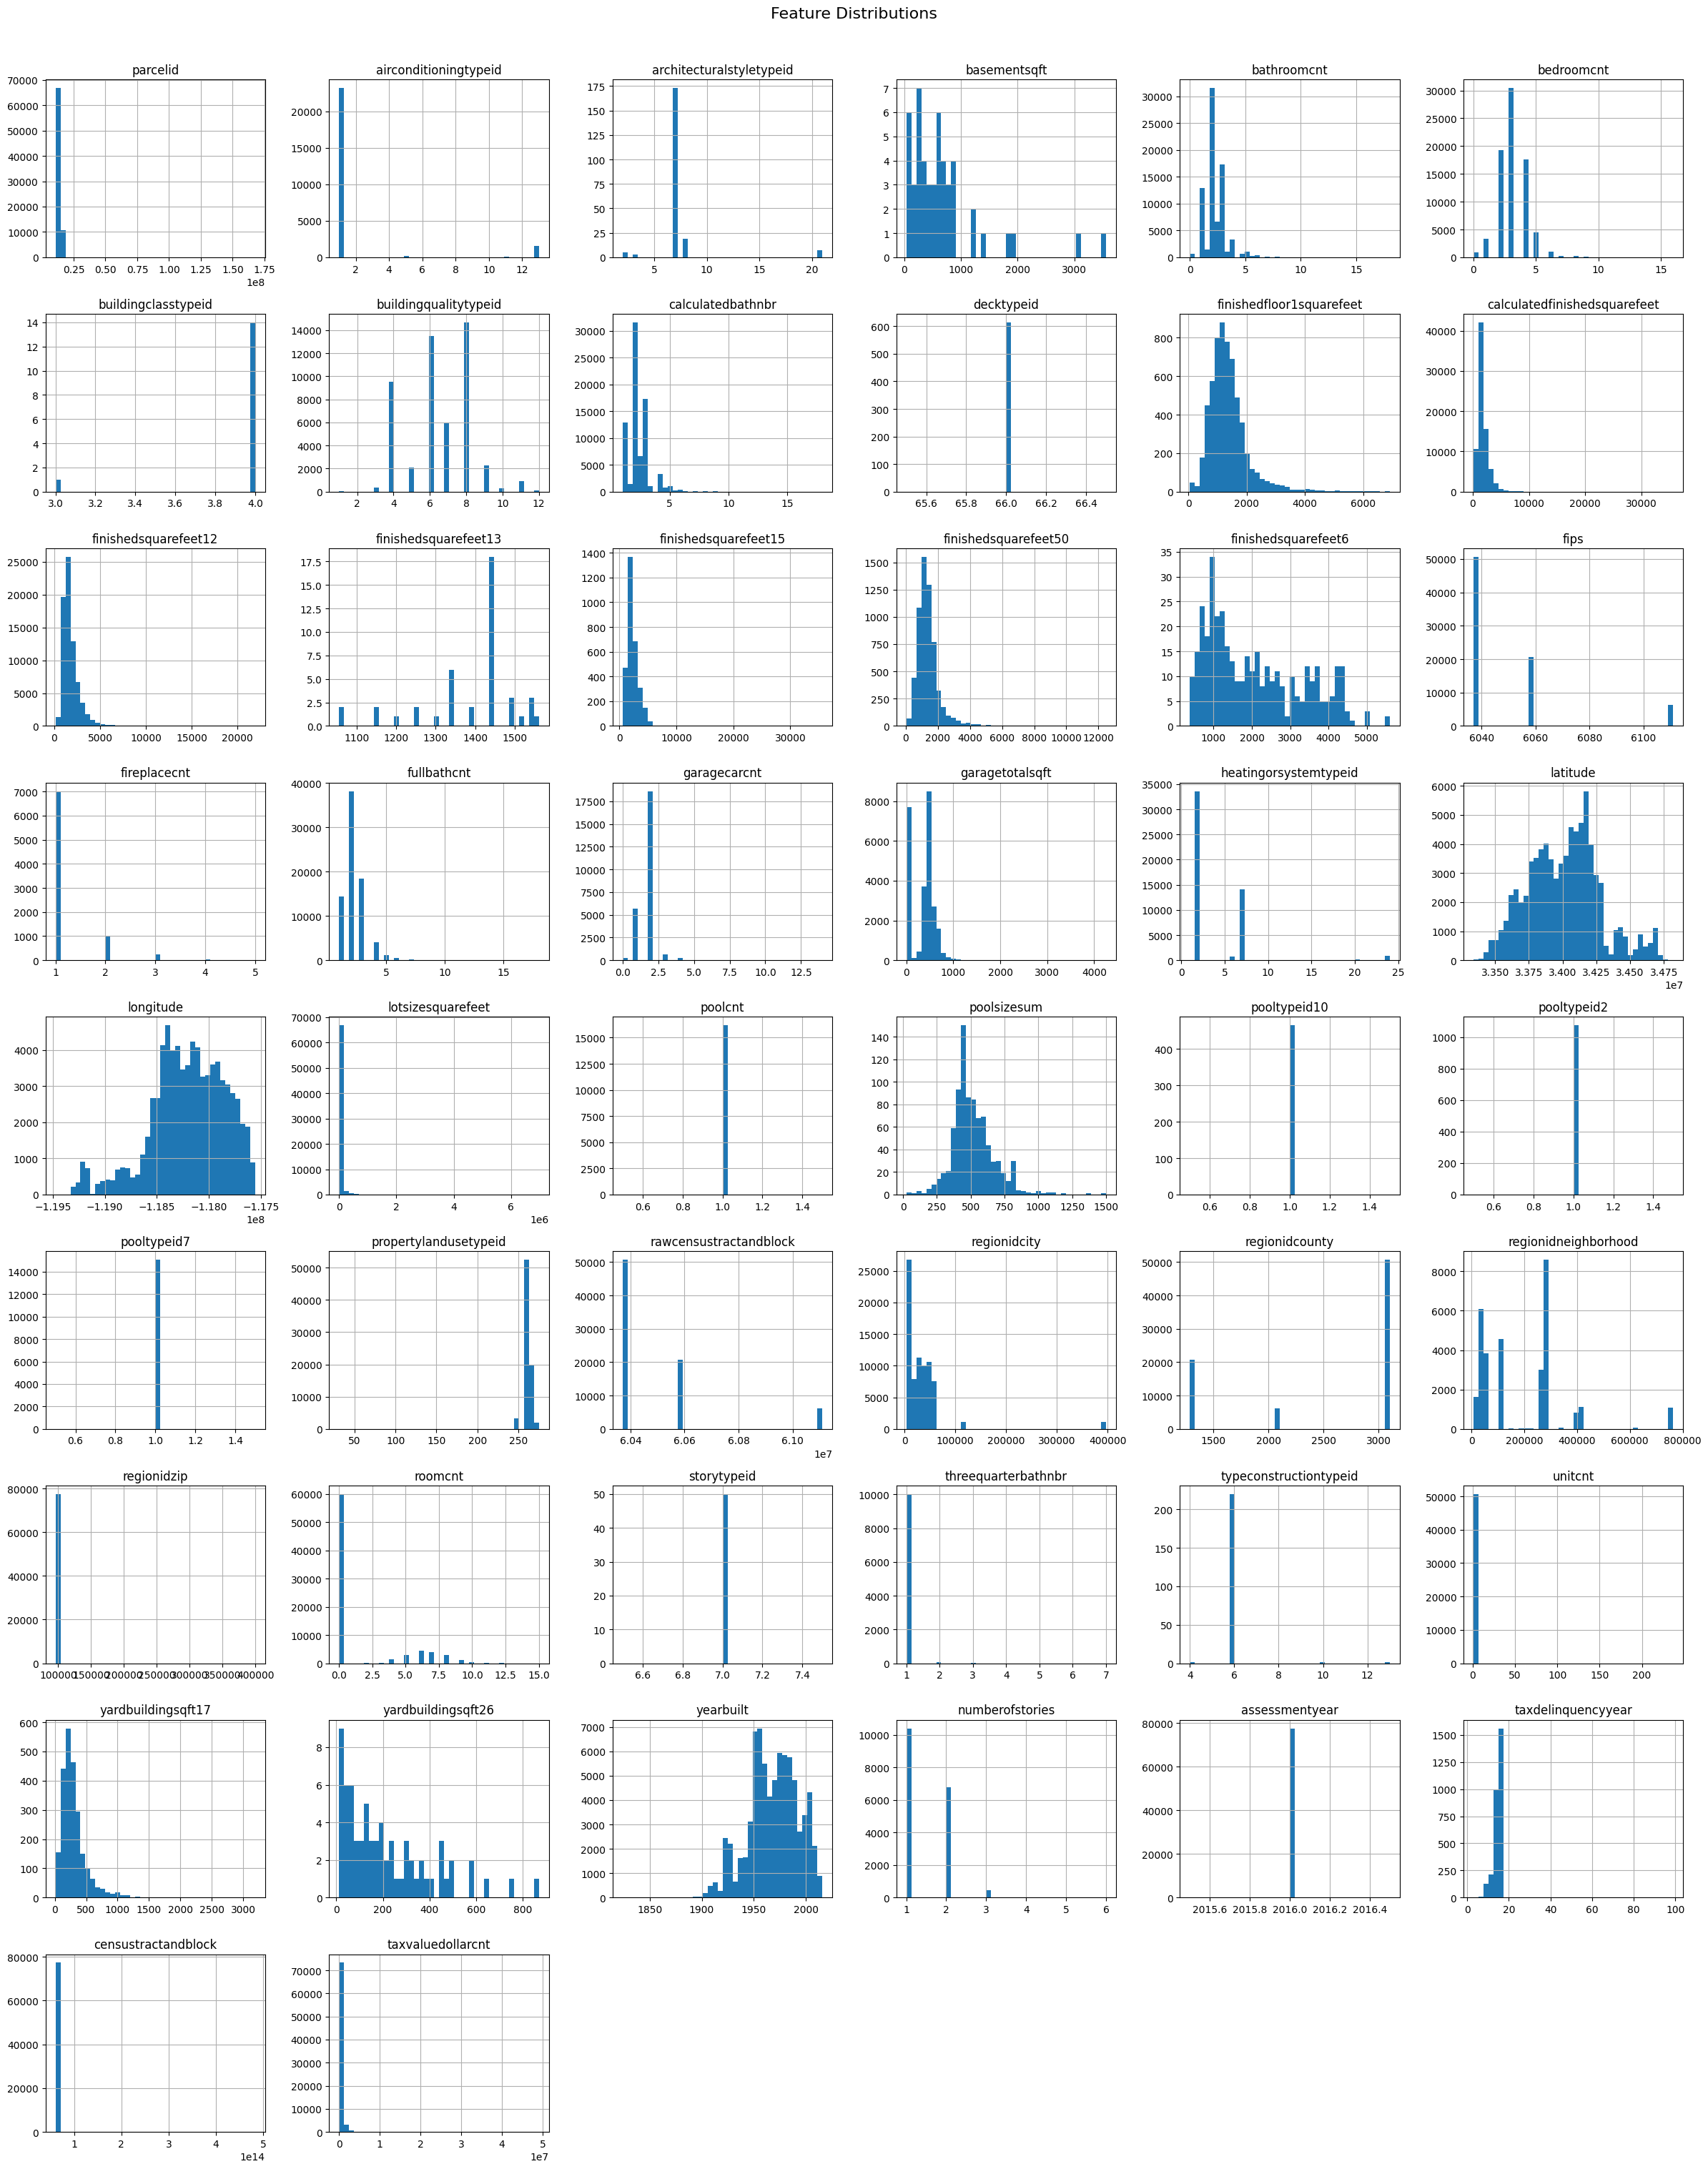

In [7]:
# Generate histograms 

df.hist(figsize=(24, 30), layout=(-1, 6), bins=40)
plt.suptitle("Feature Distributions", y=1.01, fontsize=16)
plt.tight_layout()
plt.show()

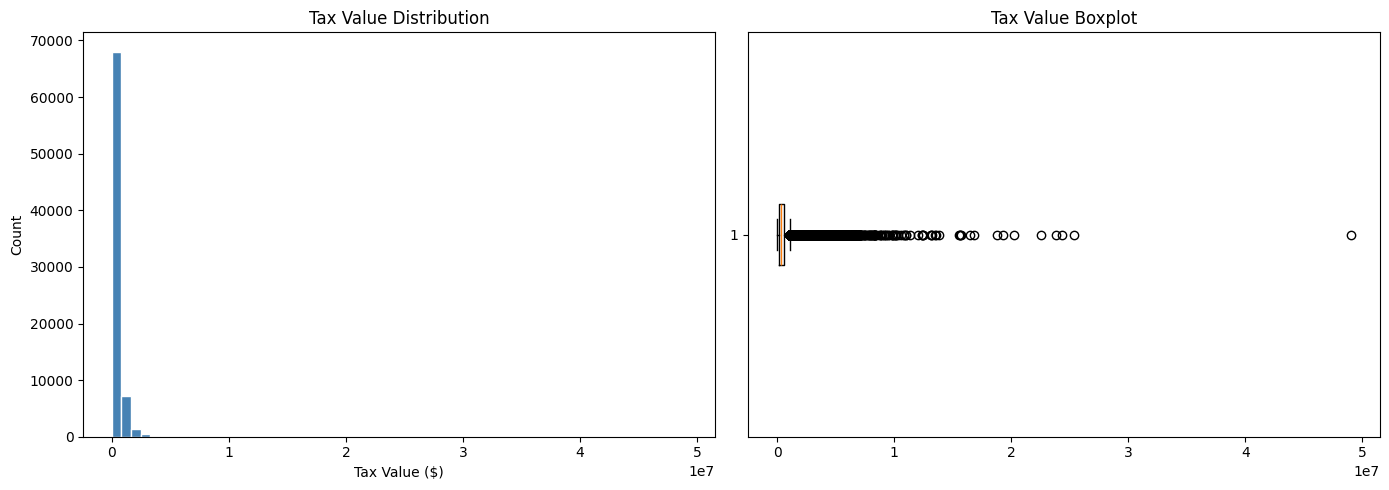

In [8]:
# taxvaluedollarcnt
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

axes[0].hist(df['taxvaluedollarcnt'].dropna(), bins=60, color='steelblue', edgecolor='white')
axes[0].set_title('Tax Value Distribution')
axes[0].set_xlabel('Tax Value ($)')
axes[0].set_ylabel('Count')

axes[1].boxplot(df['taxvaluedollarcnt'].dropna(), vert=False)
axes[1].set_title('Tax Value Boxplot')

plt.tight_layout()
plt.show()

# This shows the distribution is heavily right-skewed with significant outliers
# Most properties are valued under $1M but a few extreme values reach $50M

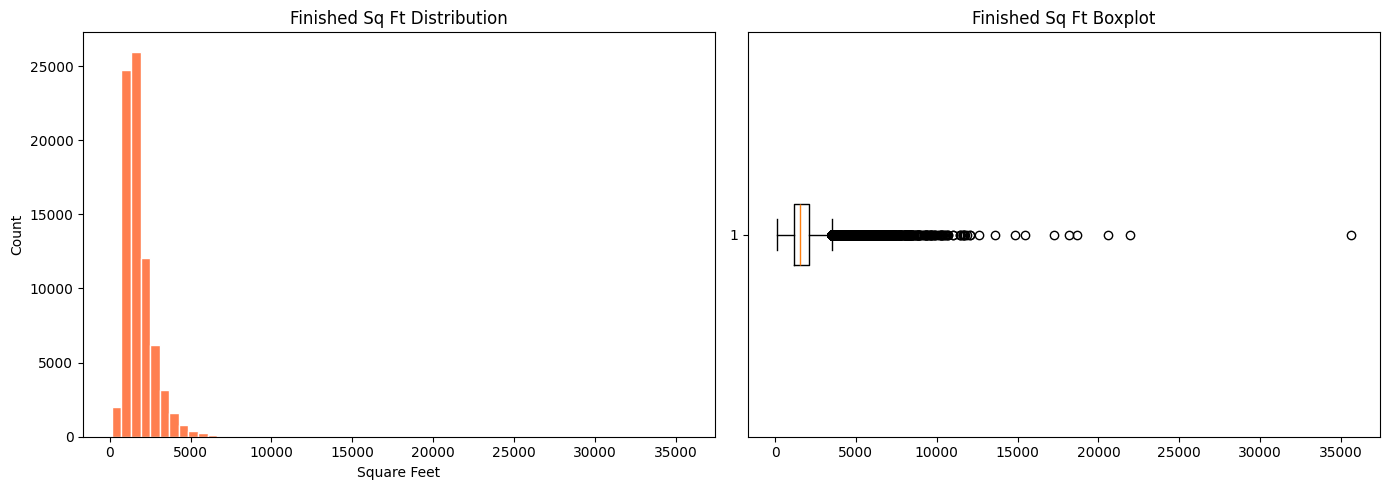

In [9]:
# calculatedfinishedsquarefeet , the total finished living area
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

axes[0].hist(df['calculatedfinishedsquarefeet'].dropna(), bins=60, color='coral', edgecolor='white')
axes[0].set_title('Finished Sq Ft Distribution')
axes[0].set_xlabel('Square Feet')
axes[0].set_ylabel('Count')

axes[1].boxplot(df['calculatedfinishedsquarefeet'].dropna(), vert=False)
axes[1].set_title('Finished Sq Ft Boxplot')

plt.tight_layout()
plt.show()

# This feature is right-skewed with most homes under 5,000 sq ft
# Several outliers exist representing unusually large properties

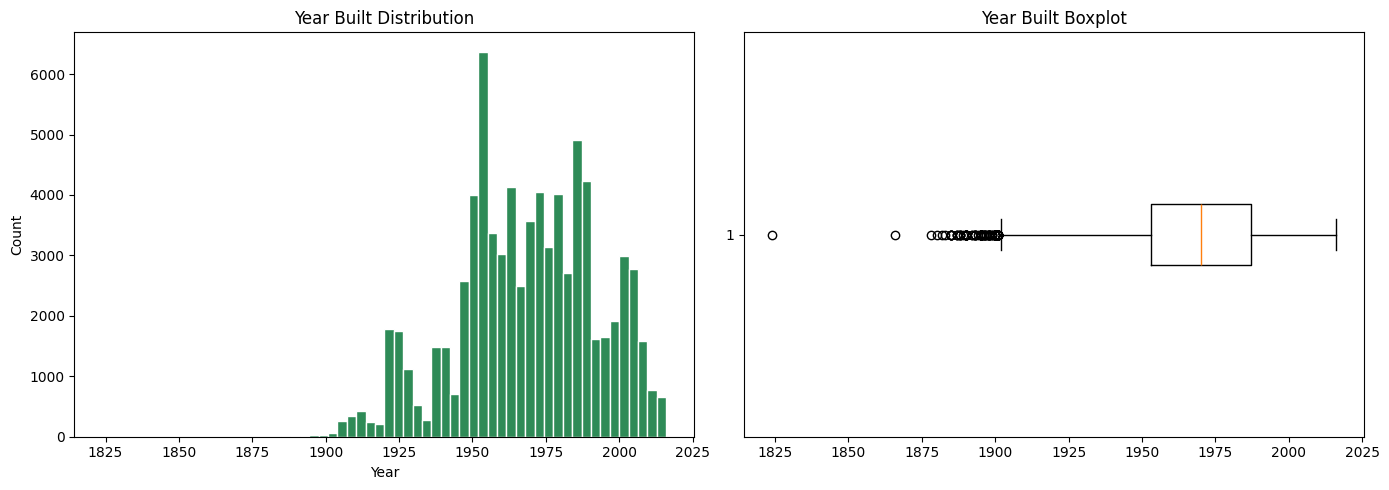

In [10]:
#  yearbuilt,  the year the property was built
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

axes[0].hist(df['yearbuilt'].dropna(), bins=60, color='seagreen', edgecolor='white')
axes[0].set_title('Year Built Distribution')
axes[0].set_xlabel('Year')
axes[0].set_ylabel('Count')

axes[1].boxplot(df['yearbuilt'].dropna(), vert=False)
axes[1].set_title('Year Built Boxplot')

plt.tight_layout()
plt.show()

# Most properties were built between 1950-2005 with a peak around the 1950s-1960s
# A few outliers exist from as far back as the 1820s

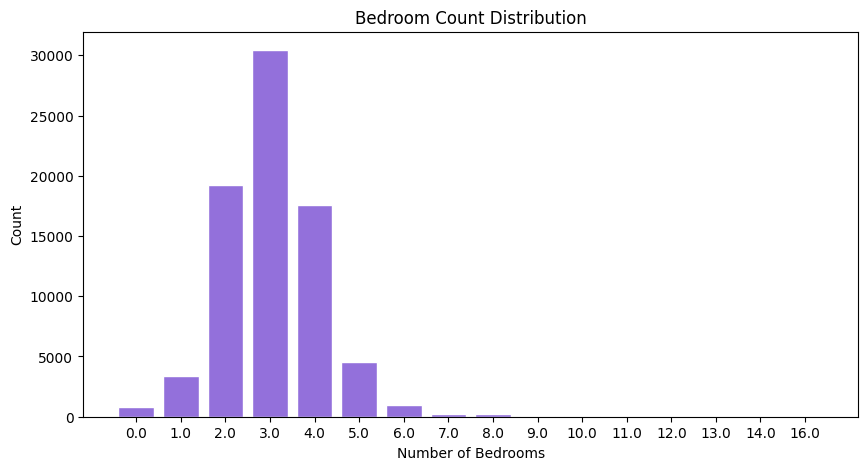

In [11]:
# bedroomcnt,  number of bedrooms
bedroom_counts = df['bedroomcnt'].value_counts().sort_index()

plt.figure(figsize=(10, 5))
plt.bar(bedroom_counts.index.astype(str), bedroom_counts.values, color='mediumpurple', edgecolor='white')
plt.title('Bedroom Count Distribution')
plt.xlabel('Number of Bedrooms')
plt.ylabel('Count')
plt.show()

# Most properties have 3-4 bedrooms which is typical for residential homes
# Properties with 0 bedrooms are likely data errors and properties with 10+ are outliers

#### **2.B Discussion:** Describe in a paragraph what you learned in your detailed examination of the features you explored:
- What is the distribution (normal, exponential, etc.) if any?
- Any problems (e.g., outliers, any odd characteristics)?
- Anything else interesting? Why did you choose it?


**What is the distribution (normal, exponential, etc.) if any?**

The target variable `taxvaluedollarcnt` follows a right-skewed distribution, 
with most properties valued under $1M. `calculatedfinishedsquarefeet` is also 
right-skewed with most homes under 5,000 sq ft. `yearbuilt` is the most 
normally distributed of the four, with most properties built between 1950-2005. 
`bedroomcnt` follows a roughly normal distribution centered around 3-4 bedrooms.

**Any problems (e.g., outliers, any odd characteristics)?**

All four features contain outliers. `taxvaluedollarcnt` has extreme values 
reaching $50M. `calculatedfinishedsquarefeet` has properties as large as 35,000 
sq ft. `yearbuilt` has a few properties dating back to the 1820s. `bedroomcnt` 
has suspicious values of 0 bedrooms and extreme values up to 16 bedrooms that 
are likely data errors.

**Anything else interesting? Why did you choose it?**

These three features are the most commonly used descriptors of a property. 
Square footage, year built, and number of bedrooms are the first things people 
look at when buying a home, so they are likely strong predictors of tax value. 
It is also interesting that despite being the most intuitive features, all three 
still contain data quality issues that will need to be addressed in the cleaning phase.

## Part 3:  Clean the Data: Drop, Impute, and Encode [6 pts]



**Important Notes:**
- You should review your Homework 4 before doing this section!
- Create new names for modified data at each stage to avoid problems with global variables.
- Whenever possible, write functions for all data transformations you apply, for these reasons:
    - So you can easily prepare the data the next time you get a fresh dataset
    - So you can apply these transformations in future projects
    - To clean and prepare new data instances once your solution is live
    - To make it easy to treat your preparation choices as hyperparameters
    - [To apply the same transformations to your test set if train/test split already done -- not applicable here]

### Part 3.A: Drop features you judge to be unsuitable for the regression task

Your call, based on any research you can do to understand the feature (hopefully IRL you would have a domain expert to help with this, but do your best).   

Note: Do not drop features because of too many missing values, that's the next task! 

In [12]:
pd.set_option('display.max_columns', None)

In [13]:
df_column_list = df.columns
df_column_list

Index(['parcelid', 'airconditioningtypeid', 'architecturalstyletypeid',
       'basementsqft', 'bathroomcnt', 'bedroomcnt', 'buildingclasstypeid',
       'buildingqualitytypeid', 'calculatedbathnbr', 'decktypeid',
       'finishedfloor1squarefeet', 'calculatedfinishedsquarefeet',
       'finishedsquarefeet12', 'finishedsquarefeet13', 'finishedsquarefeet15',
       'finishedsquarefeet50', 'finishedsquarefeet6', 'fips', 'fireplacecnt',
       'fullbathcnt', 'garagecarcnt', 'garagetotalsqft', 'hashottuborspa',
       'heatingorsystemtypeid', 'latitude', 'longitude', 'lotsizesquarefeet',
       'poolcnt', 'poolsizesum', 'pooltypeid10', 'pooltypeid2', 'pooltypeid7',
       'propertycountylandusecode', 'propertylandusetypeid',
       'propertyzoningdesc', 'rawcensustractandblock', 'regionidcity',
       'regionidcounty', 'regionidneighborhood', 'regionidzip', 'roomcnt',
       'storytypeid', 'threequarterbathnbr', 'typeconstructiontypeid',
       'unitcnt', 'yardbuildingsqft17', 'yardbuildin

In [14]:
# Get overview of how data looks in the DataFrame

df.head()

,parcelid,airconditioningtypeid,architecturalstyletypeid,basementsqft,bathroomcnt,bedroomcnt,buildingclasstypeid,buildingqualitytypeid,calculatedbathnbr,decktypeid,finishedfloor1squarefeet,calculatedfinishedsquarefeet,finishedsquarefeet12,finishedsquarefeet13,finishedsquarefeet15,finishedsquarefeet50,finishedsquarefeet6,fips,fireplacecnt,fullbathcnt,garagecarcnt,garagetotalsqft,hashottuborspa,heatingorsystemtypeid,latitude,longitude,lotsizesquarefeet,poolcnt,poolsizesum,pooltypeid10,pooltypeid2,pooltypeid7,propertycountylandusecode,propertylandusetypeid,propertyzoningdesc,rawcensustractandblock,regionidcity,regionidcounty,regionidneighborhood,regionidzip,roomcnt,storytypeid,threequarterbathnbr,typeconstructiontypeid,unitcnt,yardbuildingsqft17,yardbuildingsqft26,yearbuilt,numberofstories,fireplaceflag,assessmentyear,taxdelinquencyflag,taxdelinquencyyear,censustractandblock,taxvaluedollarcnt
0,14297519,NaN,NaN,NaN,3.5,4.0,NaN,NaN,3.5,NaN,NaN,3100.0,3100.0,NaN,NaN,NaN,NaN,6059.0,NaN,3.0,2.0,633.0,NaN,NaN,33634931.0,-117869207.0,4506.0,NaN,NaN,NaN,NaN,NaN,122,261.0,NaN,6.059063e+07,53571.0,1286.0,NaN,96978.0,0.0,NaN,1.0,NaN,NaN,NaN,NaN,1998.0,NaN,NaN,2016.0,NaN,NaN,6.059063e+13,1023282.0
1,17052889,NaN,NaN,NaN,1.0,2.0,NaN,NaN,1.0,NaN,1465.0,1465.0,1465.0,NaN,NaN,1465.0,NaN,6111.0,1.0,1.0,1.0,0.0,NaN,NaN,34449266.0,-119281531.0,12647.0,NaN,NaN,NaN,NaN,NaN,1110,261.0,NaN,6.111001e+07,13091.0,2061.0,NaN,97099.0,5.0,NaN,NaN,NaN,NaN,NaN,NaN,1967.0,1.0,NaN,2016.0,NaN,NaN,6.111001e+13,464000.0
2,14186244,NaN,NaN,NaN,2.0,3.0,NaN,NaN,2.0,NaN,NaN,1243.0,1243.0,NaN,NaN,NaN,NaN,6059.0,NaN,2.0,2.0,440.0,NaN,NaN,33886168.0,-117823170.0,8432.0,1.0,NaN,NaN,NaN,1.0,122,261.0,NaN,6.059022e+07,21412.0,1286.0,NaN,97078.0,6.0,NaN,NaN,NaN,NaN,NaN,NaN,1962.0,1.0,NaN,2016.0,NaN,NaN,6.059022e+13,564778.0
3,12177905,NaN,NaN,NaN,3.0,4.0,NaN,8.0,3.0,NaN,NaN,2376.0,2376.0,NaN,NaN,NaN,NaN,6037.0,NaN,3.0,NaN,NaN,NaN,2.0,34245180.0,-118240722.0,13038.0,1.0,NaN,NaN,NaN,1.0,0101,261.0,LCR110000*,6.037300e+07,396551.0,3101.0,NaN,96330.0,0.0,NaN,NaN,NaN,1.0,NaN,NaN,1970.0,NaN,NaN,2016.0,NaN,NaN,6.037300e+13,145143.0
4,10887214,1.0,NaN,NaN,3.0,3.0,NaN,8.0,3.0,NaN,NaN,1312.0,1312.0,NaN,NaN,NaN,NaN,6037.0,NaN,3.0,NaN,NaN,NaN,2.0,34185120.0,-118414640.0,278581.0,1.0,NaN,NaN,NaN,1.0,010C,266.0,LAR3,6.037124e+07,12447.0,3101.0,268548.0,96451.0,0.0,NaN,NaN,NaN,1.0,NaN,NaN,1964.0,NaN,NaN,2016.0,NaN,NaN,6.037124e+13,119407.0


In [15]:
# Create Function to remove columns from DataFrame where df.nunique() == 1 or over 95% of the total len(df)

def remove_columns_from_dataframe(df):
    remove_column_list = []

    for col in df:
        if df[col].nunique() == 1 or df[col].nunique() > (len(df) * 0.95):
            remove_column_list.append(col)

    return remove_column_list

In [16]:
# Create variable to stored dropped column list

columns_to_drop = remove_columns_from_dataframe(df)

In [17]:
# Remove columns from dataframe

before_nunique_num_columns = len(df.columns)
df_nunique_removal = df.drop(columns=columns_to_drop)
after_nunique_num_columns = len(df_nunique_removal.columns)
removed_nunique_count = before_nunique_num_columns - after_nunique_num_columns

In [18]:
# Validate Column Count before and after removal

print(f"DataFrame Count Before Nunique Removal: {before_nunique_num_columns}")
print(f"DataFrame Count After Nunique Removal: {after_nunique_num_columns}")
print(f"Total columns removed: {removed_nunique_count}")

DataFrame Count Before Nunique Removal: 55
DataFrame Count After Nunique Removal: 44
Total columns removed: 11


In [19]:
# Create function to remove for columns with no Variation

def df_variance_check(df):
    variation_df_checks = []
    numeric_df = df.select_dtypes(include=[np.number])

    for col in numeric_df.columns:
        if numeric_df[col].std() == 0:
            variation_df_checks.append(col)
    
    return variation_df_checks

In [20]:
# Check columns for no variation

df_variance_check(df_nunique_removal)

[]

In [21]:
# Confirm correlated pairs with correlation > 90 percent 

def pairs_w_high_correlation(df, threshold=0.90):
    numeric_df = df.select_dtypes(include=[np.number])
    
    # Calculate absolute correlation matrix
    correlation_matrix = numeric_df.corr().abs()

    # Mask the upper triangle
    upper = correlation_matrix.where(np.triu(np.ones(correlation_matrix.shape), k=1).astype(bool))

    # Stack, Filter, and Format
    high_correlation_pairs = (upper[upper > threshold]
                      .stack()
                      .reset_index())
    
    # Rename columns for clarity
    high_correlation_pairs.columns = ['Feature 1', 'Feature 2', 'Correlation']
    
    return high_correlation_pairs
    

In [22]:
columns_for_pairs_df = pairs_w_high_correlation(df_nunique_removal)

In [23]:
columns_for_pairs_df

,Feature 1,Feature 2,Correlation
0,bathroomcnt,calculatedbathnbr,1.000000
1,bathroomcnt,fullbathcnt,0.984499
2,buildingclasstypeid,lotsizesquarefeet,0.974760
3,calculatedbathnbr,fullbathcnt,0.984499
4,finishedfloor1squarefeet,finishedsquarefeet15,1.000000
5,finishedfloor1squarefeet,finishedsquarefeet50,0.958542
6,calculatedfinishedsquarefeet,finishedsquarefeet12,1.000000
7,calculatedfinishedsquarefeet,finishedsquarefeet13,1.000000
8,calculatedfinishedsquarefeet,finishedsquarefeet15,1.000000
9,calculatedfinishedsquarefeet,finishedsquarefeet6,1.000000


In [24]:
def correlated_features_to_remove(df, high_corr_pairs):
    #  Calculate null percentages for every column in the main DF once
    null_probs = (df.isnull().sum() / len(df) * 100)
    
    # Create a copy of the pairs DF to avoid modifying the original
    result_df = high_corr_pairs.copy()
    
    # Map the null percentages to Feature 1 and Feature 2
    result_df['F1_Null_Pct'] = result_df['Feature 1'].map(null_probs)
    result_df['F2_Null_Pct'] = result_df['Feature 2'].map(null_probs)
    
    # Compare the null percentage of the two features
    result_df['item_in_pair_to_remove'] = np.where(
        result_df['F1_Null_Pct'] > result_df['F2_Null_Pct'], 
        result_df['Feature 1'], 
        result_df['Feature 2']
    )
    
    return result_df

In [25]:
# Confirmation that the correct pairs were chosen

df_correlated_features_to_remove = correlated_features_to_remove(df_nunique_removal,columns_for_pairs_df)
df_correlated_features_to_remove

,Feature 1,Feature 2,Correlation,F1_Null_Pct,F2_Null_Pct,item_in_pair_to_remove
0,bathroomcnt,calculatedbathnbr,1.000000,0.043807,0.837489,calculatedbathnbr
1,bathroomcnt,fullbathcnt,0.984499,0.043807,0.837489,fullbathcnt
2,buildingclasstypeid,lotsizesquarefeet,0.974760,99.980673,10.683777,buildingclasstypeid
3,calculatedbathnbr,fullbathcnt,0.984499,0.837489,0.837489,fullbathcnt
4,finishedfloor1squarefeet,finishedsquarefeet15,1.000000,92.221664,96.099880,finishedsquarefeet15
5,finishedfloor1squarefeet,finishedsquarefeet50,0.958542,92.221664,92.221664,finishedsquarefeet50
6,calculatedfinishedsquarefeet,finishedsquarefeet12,1.000000,0.302784,4.754358,finishedsquarefeet12
7,calculatedfinishedsquarefeet,finishedsquarefeet13,1.000000,0.302784,99.945885,finishedsquarefeet13
8,calculatedfinishedsquarefeet,finishedsquarefeet15,1.000000,0.302784,96.099880,finishedsquarefeet15
9,calculatedfinishedsquarefeet,finishedsquarefeet6,1.000000,0.302784,99.502661,finishedsquarefeet6


In [26]:
# Remove columns from correlated pairs

before_pair_num_columns = len(df_nunique_removal.columns)
df_pair_removal = df_nunique_removal.drop(columns=df_correlated_features_to_remove['item_in_pair_to_remove'])
after_pair_num_columns = len(df_pair_removal.columns)
removed_pair_count = before_pair_num_columns - after_pair_num_columns

In [27]:
# Validate Column Count before and after removal

print(f"DataFrame Count Before Pair Removal: {before_pair_num_columns}")
print(f"DataFrame Count After Pair Removal: {after_pair_num_columns}")
print(f"Total columns removed: {removed_pair_count}")

DataFrame Count Before Pair Removal: 44
DataFrame Count After Pair Removal: 35
Total columns removed: 9


In [28]:
df_pair_removal.head()

,airconditioningtypeid,architecturalstyletypeid,basementsqft,bathroomcnt,bedroomcnt,buildingqualitytypeid,finishedfloor1squarefeet,calculatedfinishedsquarefeet,fips,fireplacecnt,garagecarcnt,garagetotalsqft,heatingorsystemtypeid,latitude,longitude,lotsizesquarefeet,poolsizesum,propertycountylandusecode,propertylandusetypeid,propertyzoningdesc,regionidcity,regionidcounty,regionidneighborhood,regionidzip,roomcnt,threequarterbathnbr,typeconstructiontypeid,unitcnt,yardbuildingsqft17,yardbuildingsqft26,yearbuilt,numberofstories,taxdelinquencyyear,censustractandblock,taxvaluedollarcnt
0,NaN,NaN,NaN,3.5,4.0,NaN,NaN,3100.0,6059.0,NaN,2.0,633.0,NaN,33634931.0,-117869207.0,4506.0,NaN,122,261.0,NaN,53571.0,1286.0,NaN,96978.0,0.0,1.0,NaN,NaN,NaN,NaN,1998.0,NaN,NaN,6.059063e+13,1023282.0
1,NaN,NaN,NaN,1.0,2.0,NaN,1465.0,1465.0,6111.0,1.0,1.0,0.0,NaN,34449266.0,-119281531.0,12647.0,NaN,1110,261.0,NaN,13091.0,2061.0,NaN,97099.0,5.0,NaN,NaN,NaN,NaN,NaN,1967.0,1.0,NaN,6.111001e+13,464000.0
2,NaN,NaN,NaN,2.0,3.0,NaN,NaN,1243.0,6059.0,NaN,2.0,440.0,NaN,33886168.0,-117823170.0,8432.0,NaN,122,261.0,NaN,21412.0,1286.0,NaN,97078.0,6.0,NaN,NaN,NaN,NaN,NaN,1962.0,1.0,NaN,6.059022e+13,564778.0
3,NaN,NaN,NaN,3.0,4.0,8.0,NaN,2376.0,6037.0,NaN,NaN,NaN,2.0,34245180.0,-118240722.0,13038.0,NaN,0101,261.0,LCR110000*,396551.0,3101.0,NaN,96330.0,0.0,NaN,NaN,1.0,NaN,NaN,1970.0,NaN,NaN,6.037300e+13,145143.0
4,1.0,NaN,NaN,3.0,3.0,8.0,NaN,1312.0,6037.0,NaN,NaN,NaN,2.0,34185120.0,-118414640.0,278581.0,NaN,010C,266.0,LAR3,12447.0,3101.0,268548.0,96451.0,0.0,NaN,NaN,1.0,NaN,NaN,1964.0,NaN,NaN,6.037124e+13,119407.0


Text(0.5, 1.0, 'Correlation Heatmap')

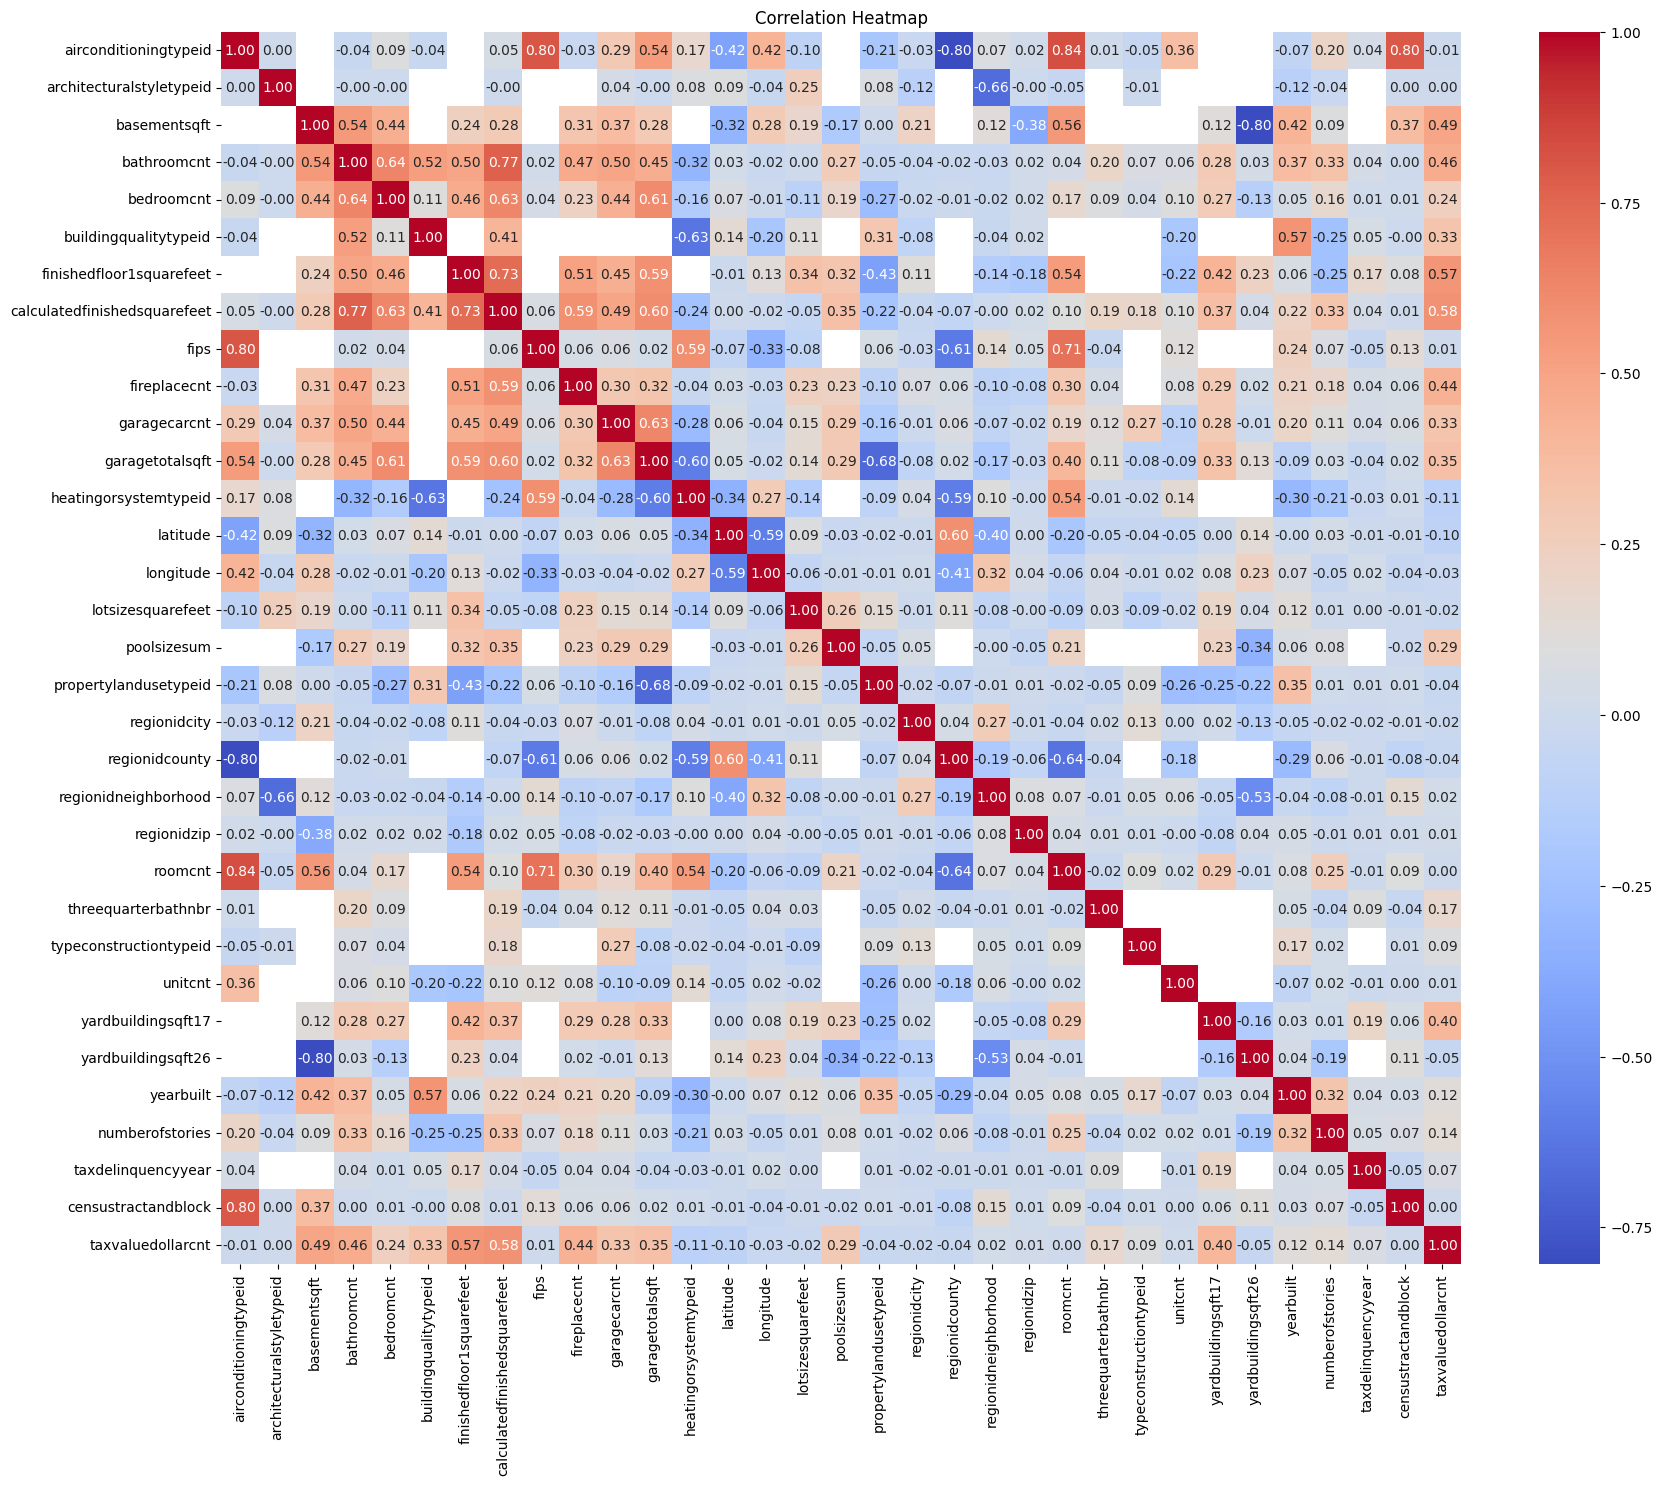

In [29]:
# Create a Correlation Map

numeric_pair_df = df_pair_removal.select_dtypes(include=['number'])

# Plot correlation map

plt.figure(figsize=(20, 16))
sns.heatmap(numeric_pair_df.corr(), annot=True, fmt=".2f", cmap='coolwarm')

plt.title("Correlation Heatmap")


#### **3.A Discussion:** Justify in a paragraph your decisions about which features to drop. 


The first reason features were dropped were based on the information gathered from nunique function. If there was only one unique value in that feature, then no information could be gathered from that feature. Likewise, if the amount on unique values in a feature were over ninety-five percent of the dataframe length, then the feature also provided little data and was close to being a key column. Also checked for features with no variance (std=0) to remove those. Lastly, checked for feature pairs that had a correlation .90 and removed one of those features based on which feature in the pair had a higher percentage of null values or the second feature is the null percentage are the same. The reason for this check is that is pairs of data are that highly correlated then having both of those columns who be redundant. 

### Part 3.B: Drop **features** with "too many" null values

Your code in the next cell(s). Make a judgement call about what "too many" means and briefly describe your reasoning in the discussion.   

Note: "Too many" may depend on what the non-null values look like, be sure to investigate carefully. 

In [30]:
# Create function to remove columns where missing > 80%

def remove_columns_for_missing_data(df):
    missing_data = (df.isnull().sum() / len(df) * 100).sort_values(ascending=False)
    missing_data_list = []

    for col in df.columns:
        if missing_data.loc[col] > 80:
            missing_data_list.append(col)

    return missing_data_list

In [31]:
# Create variable to stored dropped column list

columns_w_missing_to_drop = remove_columns_for_missing_data(df_pair_removal)

In [32]:
# Remove columns from dataframe

before_null_num_columns = len(df_pair_removal.columns)
df_null_removal = df_pair_removal.drop(columns=columns_w_missing_to_drop)
after_null_num_columns = len(df_null_removal.columns)
removed_null_count = before_null_num_columns - after_null_num_columns

In [33]:
# Validate Column Count before and after removal

print(f"DataFrame Count Before Null Removal: {before_null_num_columns}")
print(f"DataFrame Count After Null Removal: {after_null_num_columns}")
print(f"Total columns removed: {removed_null_count}")

DataFrame Count Before Null Removal: 35
DataFrame Count After Null Removal: 25
Total columns removed: 10


Text(0.5, 1.0, 'Correlation Heatmap')

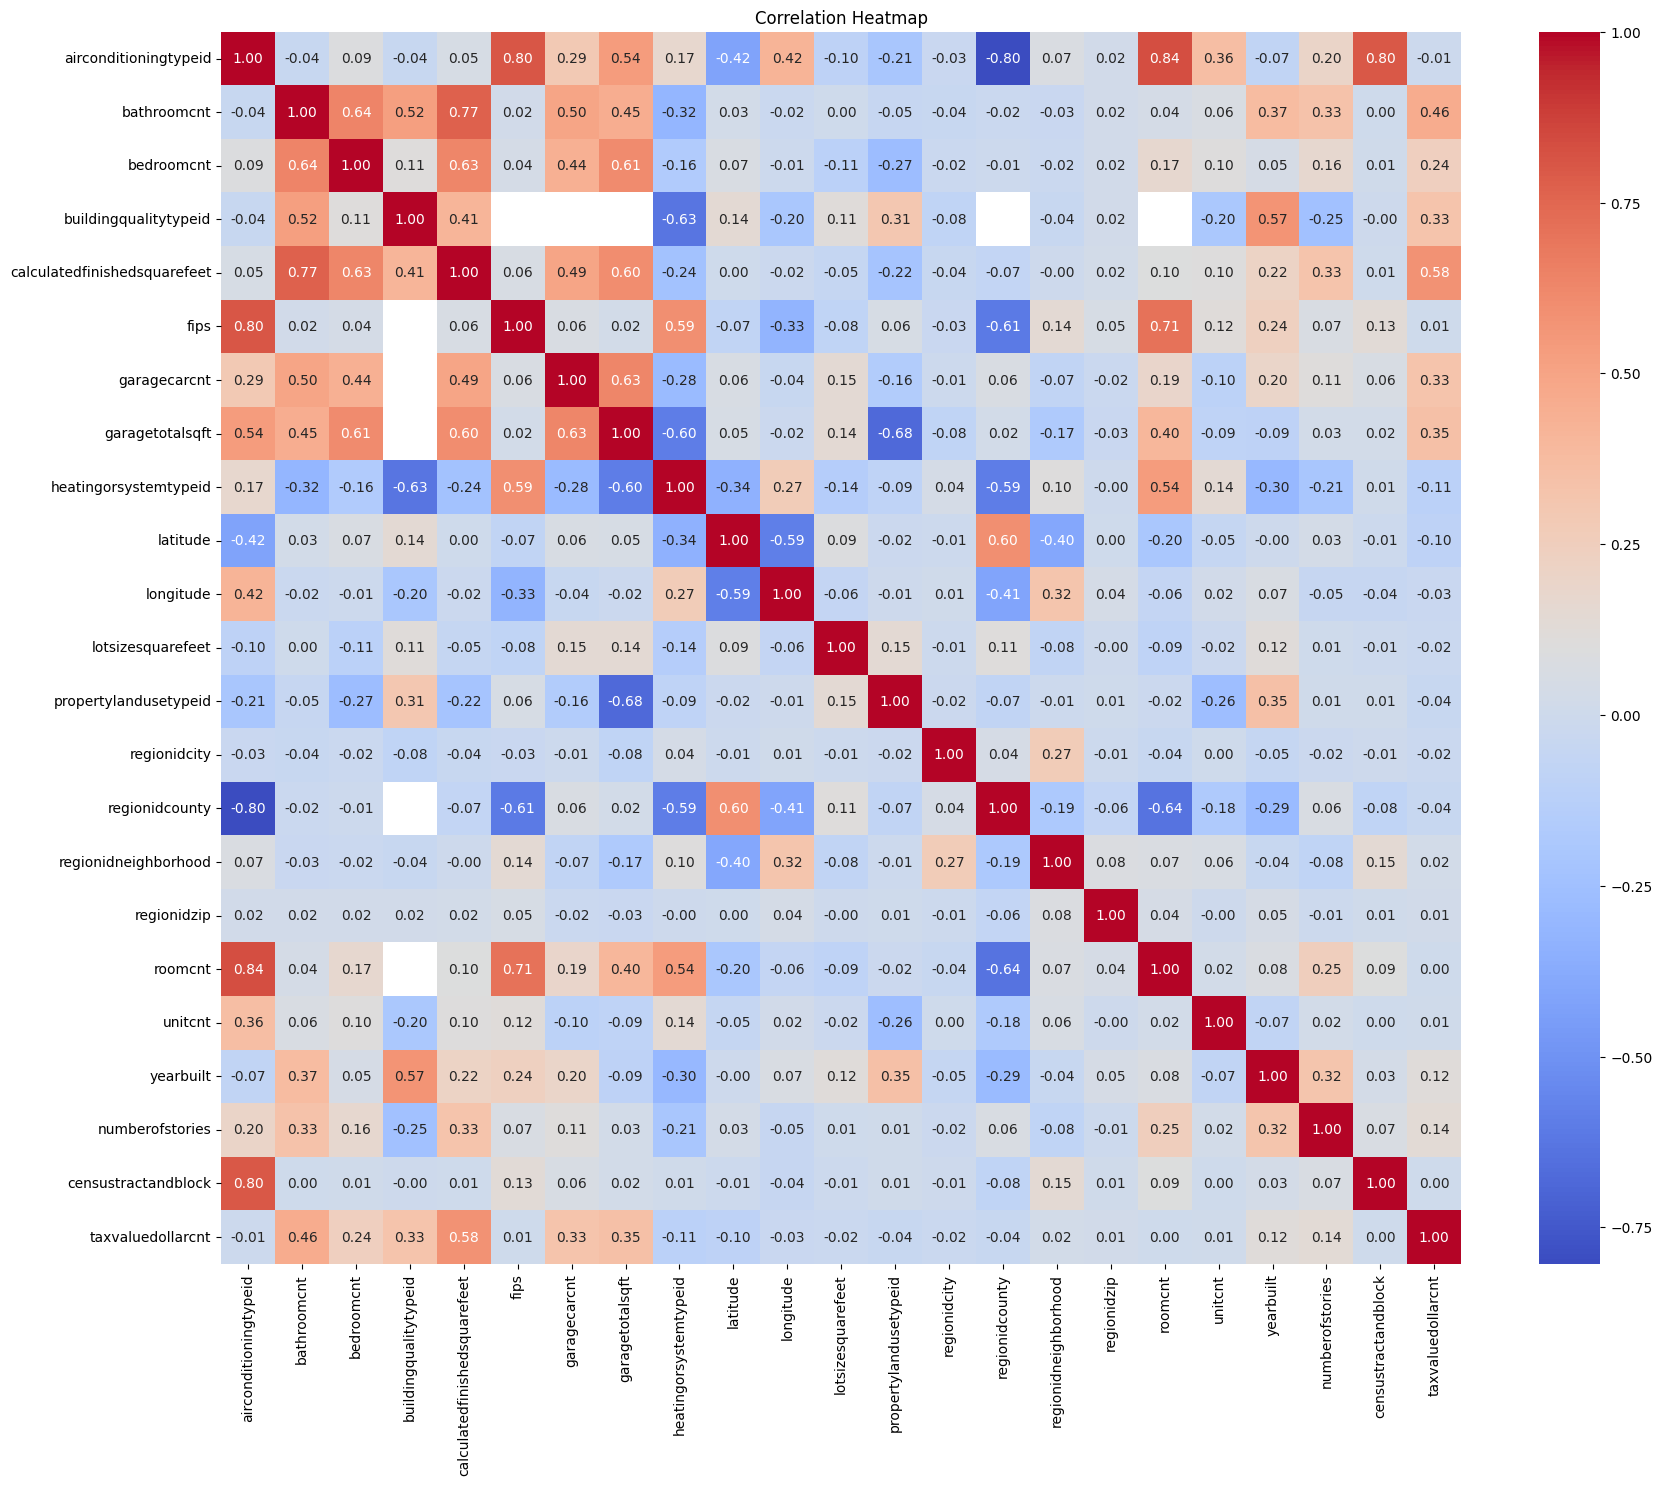

In [34]:
# Create a Correlation Map

numeric_pair_df = df_null_removal.select_dtypes(include=['number'])

# Plot correlation map

plt.figure(figsize=(20, 16))
sns.heatmap(numeric_pair_df.corr(), annot=True, fmt=".2f", cmap='coolwarm')

plt.title("Correlation Heatmap")


In [35]:
# Total Columns Removed

total_columns_removed = len(df.columns) - len(df_null_removal.columns)
print(f"Total Columns Removed from 3.A and 3.B: {total_columns_removed}")

Total Columns Removed from 3.A and 3.B: 30


#### **3.B Discussion:** In a paragraph, explain your decision about which features were dropped



There were a total of 10 features removed based on the volume of null values that were present in the column. Features that had over eighty percent of the values as null were removed. At this range, even imputing the null values would make it so no useful patterns would be able to be seen.  

### Part 3.C: Drop Problematic **samples** 

There could be several reasons why you might want to drop a sample:
- It has  "too many" null values 
- It has a null value in the target
- It contains outliers, especially in the target



Your code in the next cell(s). Make a judgement call about which samples should be dropped and briefly describe your reasoning in the discussion.   


In [36]:
df_new = df_null_removal.copy()

In [37]:
# Create function to check for column with null value in target

def null_in_target(df, target_column = 'taxvaluedollarcnt'):
    null_target_rows = df[df[target_column].isnull()].index.tolist()
    
    return null_target_rows

In [38]:
# Run check for null target functions

null_target_rows = null_in_target(df_new)
df_clean = df_new.drop(index=null_target_rows)

In [39]:
# Check before and after row counts

before_null_target_removal = len(df_new)
after_null_target_removal = len(df_clean)
total_target_removal = before_null_target_removal - after_null_target_removal
print(f"Total number of rows before: {before_null_target_removal}")
print(f"Total number of rows after: {after_null_target_removal}")
print(f"Total number of rows removed: {total_target_removal}")

Total number of rows before: 77613
Total number of rows after: 77578
Total number of rows removed: 35


In [40]:
# Check percentage of null values for a row > 50%

def percentage_of_null_columns(df, threshold=50):
    # Calculate the percentage of nulls for each row (axis=1)
    row_nulls = (df.isnull().sum(axis=1) / len(df.columns)) * 100
    
    # Filter for rows that are above the threshold
    high_null_rows = row_nulls[row_nulls > threshold].index.tolist()
    
    return high_null_rows

In [41]:
# Run check for 50% value are null function

percentage_rows_to_drop = percentage_of_null_columns(df_clean)
df_clean_new = df_clean.drop(index=percentage_rows_to_drop)

In [42]:
# Check before and after row counts

before_percentage_target_removal = len(df_clean)
after_percentage_target_removal = len(df_clean_new)
total_percentage_target_removal = before_percentage_target_removal - after_percentage_target_removal
print(f"Total number of rows before: {before_percentage_target_removal}")
print(f"Total number of rows after: {after_percentage_target_removal}")
print(f"Total number of rows removed: {total_percentage_target_removal}")

Total number of rows before: 77578
Total number of rows after: 77568
Total number of rows removed: 10


In [43]:
# Check for all columns in list

def outliers_for_removal_full(df, column_list):
    
    all_outlier_indices = set()

    for col in column_list:
        # Calculate Q1 (25th percentile) and Q3 (75th percentile)
        Q1 = df[col].quantile(0.25)
        Q3 = df[col].quantile(0.75)
        IQR = Q3 - Q1
        
        # Define the lower and upper bounds using Q1 and Q3
        lower_bound = Q1 - (1.5 * IQR)
        upper_bound = Q3 + (1.5 * IQR)
        
        # Identify rows index not inside of defined bounds
        column_outliers = df[(df[col] < lower_bound) | (df[col] > upper_bound)].index
        
        # Append indices to set
        all_outlier_indices.update(column_outliers)
        
        print(f"Column '{col}': Found {len(column_outliers)} outliers.")

    return 

In [44]:
new_numeric_list = df_clean_new.select_dtypes(include=['number'])

df_clean_new_list = list(new_numeric_list.columns)

target_outliers_for_removal_full = outliers_for_removal_full(df_clean_new,df_clean_new_list)

Column 'airconditioningtypeid': Found 1821 outliers.
Column 'bathroomcnt': Found 2581 outliers.
Column 'bedroomcnt': Found 383 outliers.
Column 'buildingqualitytypeid': Found 151 outliers.
Column 'calculatedfinishedsquarefeet': Found 4006 outliers.
Column 'fips': Found 6251 outliers.
Column 'garagecarcnt': Found 6881 outliers.
Column 'garagetotalsqft': Found 62 outliers.
Column 'heatingorsystemtypeid': Found 977 outliers.
Column 'latitude': Found 113 outliers.
Column 'longitude': Found 2210 outliers.
Column 'lotsizesquarefeet': Found 11408 outliers.
Column 'propertylandusetypeid': Found 3362 outliers.
Column 'regionidcity': Found 2142 outliers.
Column 'regionidcounty': Found 0 outliers.
Column 'regionidneighborhood': Found 1141 outliers.
Column 'regionidzip': Found 12 outliers.
Column 'roomcnt': Found 17612 outliers.
Column 'unitcnt': Found 3290 outliers.
Column 'yearbuilt': Found 113 outliers.
Column 'numberofstories': Found 1 outliers.
Column 'censustractandblock': Found 6233 outlier

In [45]:
## Stored outlier data in variable outliers_for_removal_full but did not remove from dataset
## Further analysis should be completed before removal

In [46]:
# Creating for outliers in value data:

def outliers_for_removal(df, column_name):
    # Calculate Q1 (25th percentile) and Q3 (75th percentile)
    Q1 = df[column_name].quantile(0.25)
    Q3 = df[column_name].quantile(0.75)
    
    # Calculate the IQR (The middle 50% of the data)
    IQR = Q3 - Q1
    
    # Define the lower and upper bounds using Q1 and Q3
    lower_bound = Q1 - (1.5 * IQR)
    upper_bound = Q3 + (1.5 * IQR)
    
    # Identify rows index not inside of defined bounds
    outliers = df[(df[column_name] < lower_bound) | (df[column_name] > upper_bound)].index.tolist()
    
    return outliers

In [47]:
# Identify and Remove Samples with Outliers in Target Column

target_outliers_for_removal = outliers_for_removal(df_clean_new, 'taxvaluedollarcnt')
df_clean_removal = df_clean_new.drop(index=target_outliers_for_removal)

In [48]:
# Check before and after row counts

before_outlier_target_removal = len(df_clean_new)
after_outlier_target_removal = len(df_clean_removal)
total_outlier_target_removal = before_outlier_target_removal - after_outlier_target_removal
print(f"Total number of rows before: {before_outlier_target_removal}")
print(f"Total number of rows after: {after_outlier_target_removal}")
print(f"Total number of rows removed: {total_outlier_target_removal}")

Total number of rows before: 77568
Total number of rows after: 72384
Total number of rows removed: 5184


In [49]:
df_clean_removal.info()

<class 'pandas.core.frame.DataFrame'>
Index: 72384 entries, 0 to 77612
Data columns (total 25 columns):
 #   Column                        Non-Null Count  Dtype  
---  ------                        --------------  -----  
 0   airconditioningtypeid         23165 non-null  float64
 1   bathroomcnt                   72384 non-null  float64
 2   bedroomcnt                    72384 non-null  float64
 3   buildingqualitytypeid         46638 non-null  float64
 4   calculatedfinishedsquarefeet  72246 non-null  float64
 5   fips                          72384 non-null  float64
 6   garagecarcnt                  23769 non-null  float64
 7   garagetotalsqft               23769 non-null  float64
 8   heatingorsystemtypeid         46349 non-null  float64
 9   latitude                      72384 non-null  float64
 10  longitude                     72384 non-null  float64
 11  lotsizesquarefeet             64370 non-null  float64
 12  propertycountylandusecode     72384 non-null  object 
 13  proper

#### **3.C Discussion:** In a short paragraph, explain your decision about which samples were dropped


Removed samples based on three different methods. First checked to see if the target column had null values. If so, those samples were removed. Then created a function which checked to see is a sample have more than 50% of their values as null, and another function to identify and remove samples with outliers in the target columns. Another function we created to identify outliers all of the other features present too but they were not removed as additional analysis should be completed first. 

### Part 3.D: Impute for the remaining missing values

Review the methods for imputation in **Appendix 2** and choose how you will impute the remainder of the missing values. Note:
- Consider whether different methods are justified for different features.
- In the next cells, apply your imputation methods to the dataset so that no null values remain after this step.
- Answer the discussion question.

In [50]:
# Mean Imputation Normal Skew Data
# Median Imputation Skewed Data

# Used function to identify skewness and then applies mean or median imputation based on that:

def mean_or_median_impute(df):
    df_imputed = df.copy()
    
    # Select only numeric columns
    numeric_cols = df_imputed.select_dtypes(include=[np.number]).columns
    
    for col in numeric_cols:
        if df_imputed[col].isnull().sum() > 0:
            # Calculate Skewness
            skew_val = df_imputed[col].skew()
            
            if -0.5 <= skew_val <= 0.5:
                # Normal Distribution
                fill_val = df_imputed[col].mean()
                strategy = "Mean"
            else:
                # Skewed Distribution
                fill_val = df_imputed[col].median()
                strategy = "Median"
            
            # Apply the fill
            df_imputed[col] = df_imputed[col].fillna(fill_val)
            print(f"Column '{col}': Skew={skew_val:.2f} -> Filled with {strategy} ({fill_val:.2f})")
            
    return df_imputed


In [51]:
# Apply imputation to dataframe

df_imputed = mean_or_median_impute(df_clean_removal)

Column 'airconditioningtypeid': Skew=3.38 -> Filled with Median (1.00)
Column 'buildingqualitytypeid': Skew=-0.10 -> Filled with Mean (6.41)
Column 'calculatedfinishedsquarefeet': Skew=1.46 -> Filled with Median (1495.00)
Column 'garagecarcnt': Skew=0.50 -> Filled with Mean (1.78)
Column 'garagetotalsqft': Skew=-0.01 -> Filled with Mean (330.01)
Column 'heatingorsystemtypeid': Skew=3.23 -> Filled with Median (2.00)
Column 'lotsizesquarefeet': Skew=24.77 -> Filled with Median (7145.00)
Column 'regionidcity': Skew=6.29 -> Filled with Median (25218.00)
Column 'regionidneighborhood': Skew=1.39 -> Filled with Median (118849.00)
Column 'regionidzip': Skew=98.80 -> Filled with Median (96398.00)
Column 'unitcnt': Skew=160.51 -> Filled with Median (1.00)
Column 'yearbuilt': Skew=-0.32 -> Filled with Mean (1968.21)
Column 'numberofstories': Skew=0.77 -> Filled with Median (1.00)
Column 'censustractandblock': Skew=261.79 -> Filled with Median (60376023023006.00)


#### **3.D Discussion:**  Describe in a paragraph your decisions about which methods you used to impute missing values in the dataset


Created a function that would identify how the data in a feature is skewed. If the data has a normal skew then mean imputation would be used and if the data was skewed left or right then median imputation would be used. Removal of null samples has already been applied in previous steps didn't want to remove more data as it could be removing valuable information. Since mode imputation can case bias, a constant value can mislead data and unknown category can introduce an artifical category those methods were not used. 

### 3.E: Encode the Categorical Features (if any)

You may not have any categorical features. If you do, encode them in the next step. No discussion is necessary. 

In [52]:
# Identify and encode the categorical values

def encode_categorical_features(df):
    # Identify non-numeric columns (object or str)
    categorical_columns = df.select_dtypes(include=['object', 'category']).columns.tolist()
    
    if not categorical_columns:
        print("No categorical columns found.")
        return df, None

    print(f"Encoding columns: {categorical_columns}")

    # Use Encoder
    encoder = OrdinalEncoder(handle_unknown='use_encoded_value', unknown_value=-1)

    # Create a copy of dataframe
    df_encoded = df.copy()

    # Fit and Transform columns
    df_encoded[categorical_columns] = encoder.fit_transform(df_encoded[categorical_columns].astype(str))

    return df_encoded, encoder

In [53]:
# Create a function that checks for non numeric values and then 

encoded_df, encorder = encode_categorical_features(df_imputed)

Encoding columns: ['propertycountylandusecode', 'propertyzoningdesc']


In [54]:
# Verify encoded columns

encoded_df[['propertycountylandusecode', 'propertyzoningdesc']].info()


<class 'pandas.core.frame.DataFrame'>
Index: 72384 entries, 0 to 77612
Data columns (total 2 columns):
 #   Column                     Non-Null Count  Dtype  
---  ------                     --------------  -----  
 0   propertycountylandusecode  72384 non-null  float64
 1   propertyzoningdesc         72384 non-null  float64
dtypes: float64(2)
memory usage: 1.7 MB


## Part 4:  Investigate Feature Relationships  [6 pts]

In this part, we will investigate the feature relationships as a way of understanding the data.  In the next part, we'll investigate potential feature engineering opportunities.

**Note:**  We won't be committing to any changes to the data until Milestone 2, as our choice of transformations will very much depend on the model we're building. But investigating these aspects of the data is an essential step in the first stages of our project. 

### Part 4.A:

   - Compute and analyze pairwise correlations using a correlation matrix.
   - Compute the F-statistic for all features for a better view of the relationships (displaying them in a bar chart would be useful as well). 
   - Identify features with strong correlations or notable relationships that may impact model performance.
   - Investigate forward and backward feature selection
        - Run these algorithms to investigate possible feature selection (don't commit to any selections yet)

Your code below, in multiple cells with descriptive comments. 

Text(0.5, 1.0, 'Encoded Correlation Heatmap')

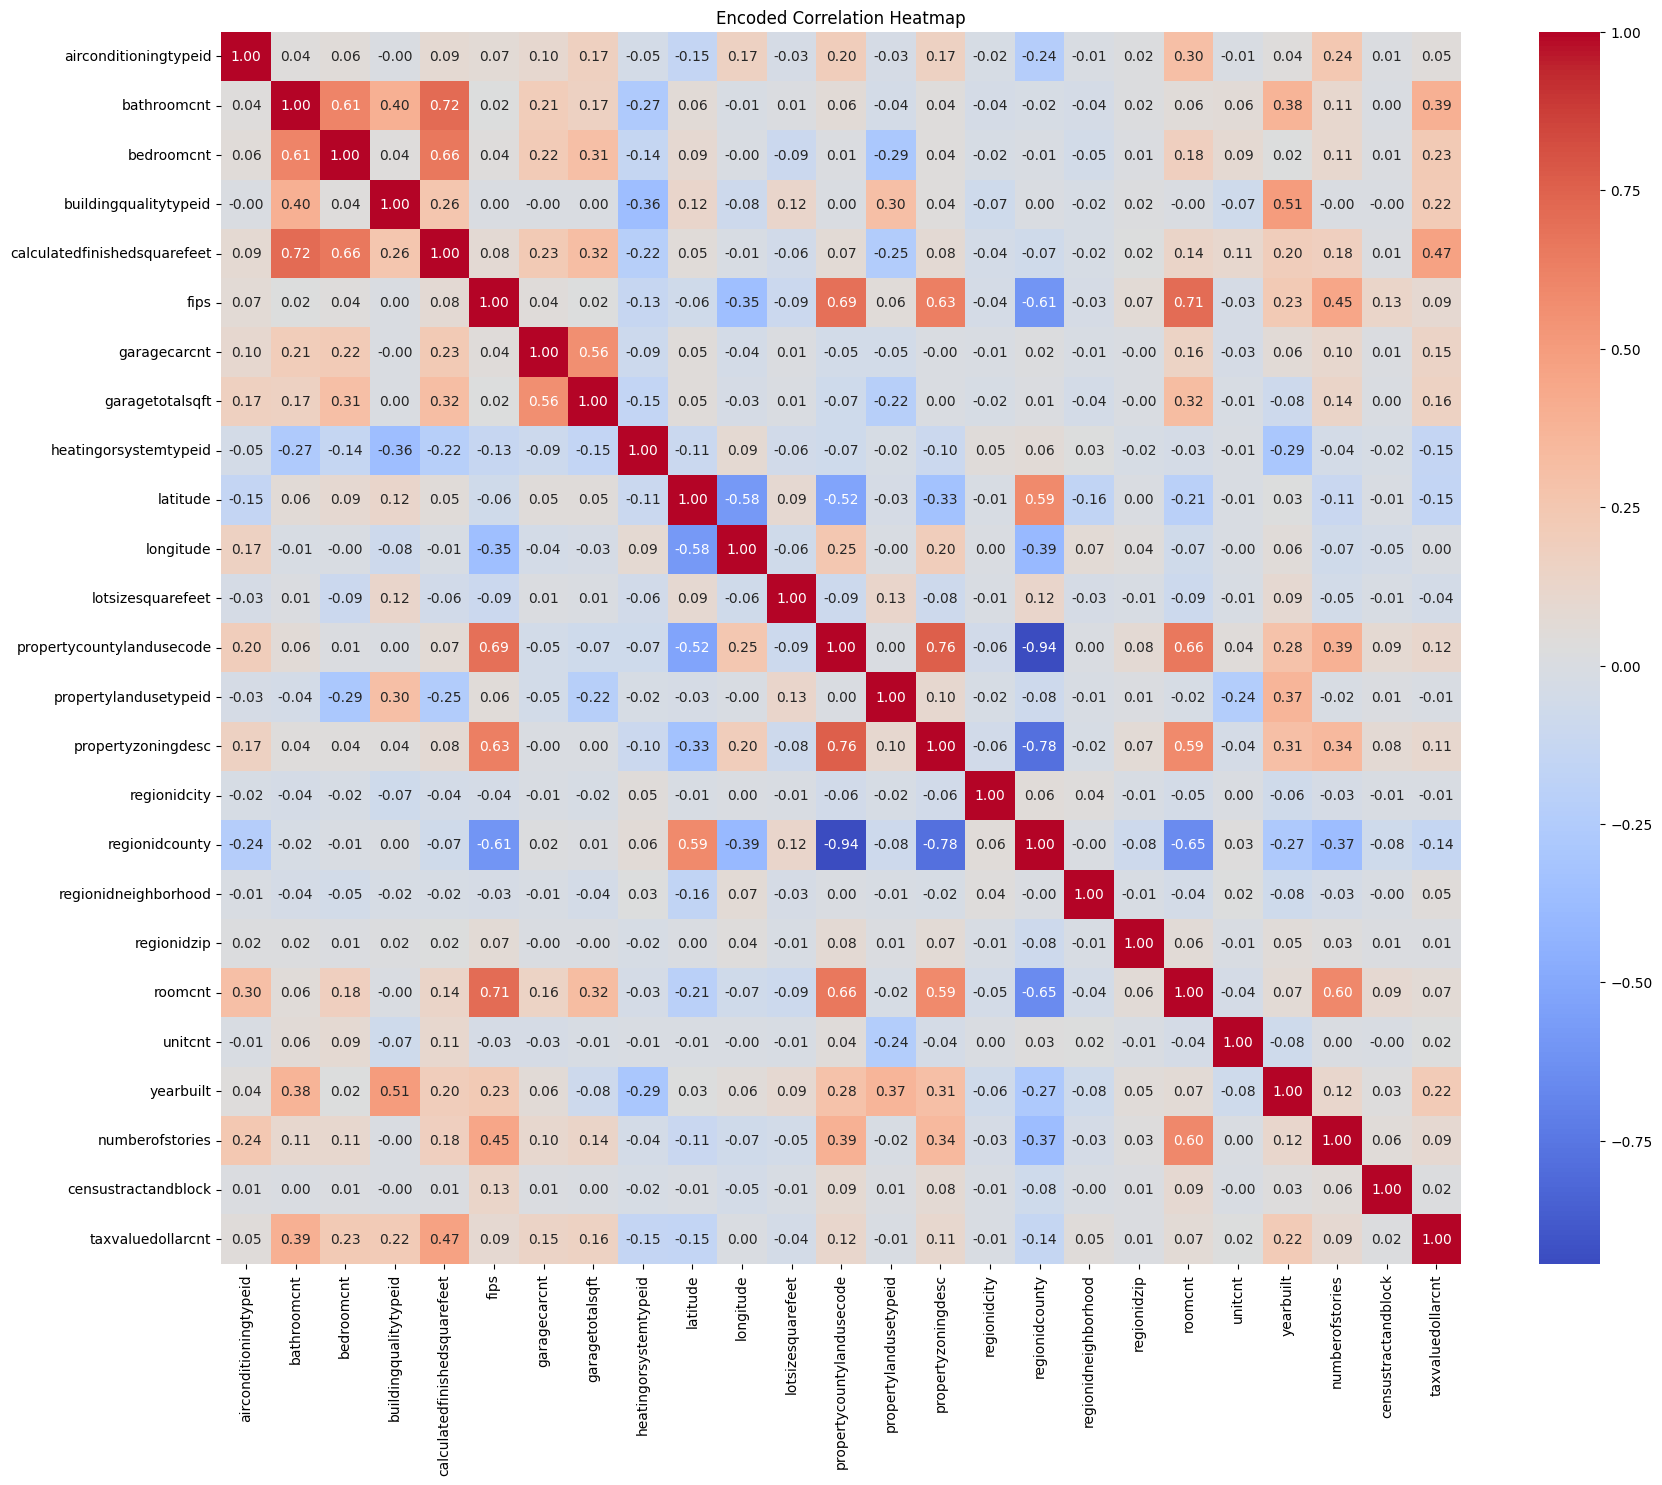

In [66]:
# Plot correlation map

plt.figure(figsize=(20, 16))
sns.heatmap(encoded_df.corr(), annot=True, fmt=".2f", cmap='coolwarm')

plt.title("Encoded Correlation Heatmap")

In [79]:
# F-statistic computed:

X = encoded_df.drop(columns =["taxvaluedollarcnt"])
y = encoded_df["taxvaluedollarcnt"]
col_df = pd.DataFrame(X.columns, columns=["column"])
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)
y_scaled = scaler.fit_transform(y.values.reshape(-1, 1)).flatten() 

f_scores, p_values = f_regression(X_scaled, y_scaled)

f_score_matrix = pd.DataFrame(f_scores.reshape(1, -1), columns=col_df, index=["F-Score"])

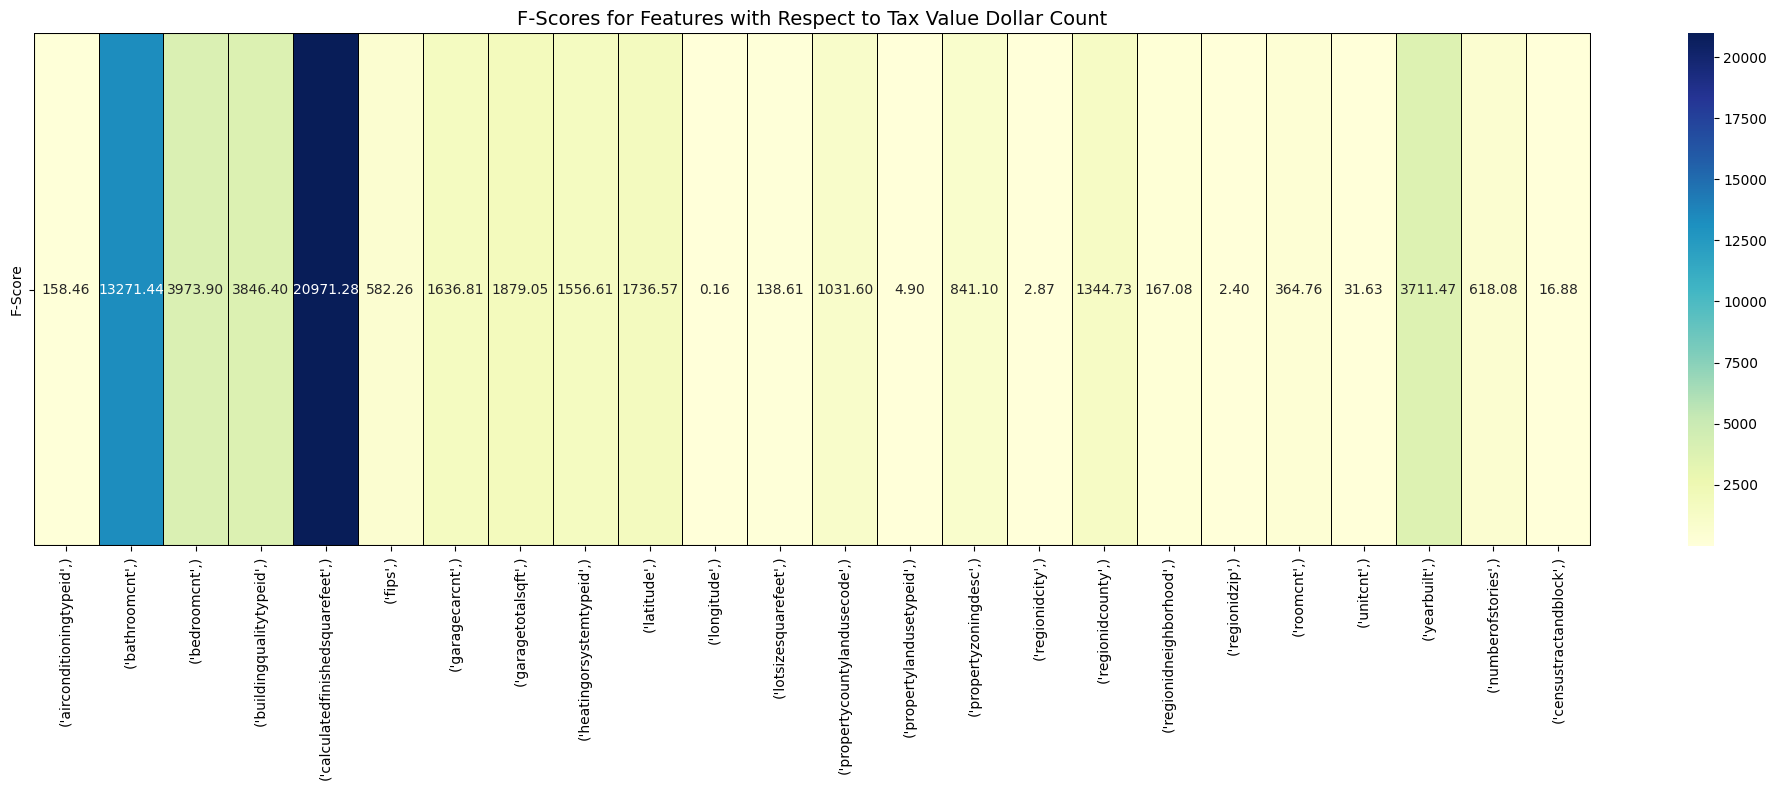

In [87]:
#F-statistic Heat Map

plt.figure(figsize=(20, 8))
ax = sns.heatmap(
    f_score_matrix,
    annot=True,
    cmap="YlGnBu",
    cbar=True,
    fmt=".2f",
    linewidths=0.5,  
    linecolor="black",  
    xticklabels=f_score_matrix.columns,
    yticklabels=f_score_matrix.index
)


ax.add_patch(patches.Rectangle(
    (0, 0),  
    f_score_matrix.shape[1], 
    f_score_matrix.shape[0], 
    edgecolor='black',  
    fill=False,  
    lw=1.5  
))

plt.title("F-Scores for Features with Respect to Tax Value Dollar Count", fontsize=14)
plt.tight_layout()
plt.show()

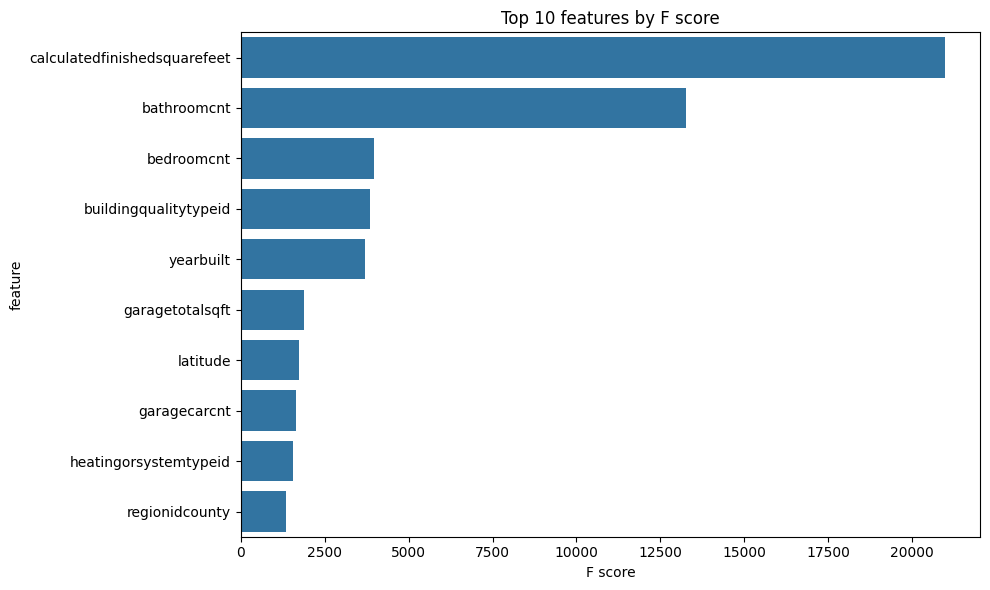

In [91]:
#report F-Scores as a decending bar chart

results = pd.DataFrame({
"feature": X.columns,
"F_score": f_scores,
}).sort_values("F_score", ascending=False).reset_index(drop=True)

topN = 10
plt.figure(figsize=(10, 6))
sns.barplot(x="F_score", y="feature", data=results.head(topN))
plt.xlabel("F score")
plt.title(f"Top {topN} features by F score")
plt.tight_layout()
plt.show()

It looks like from the F-Score that the calculated Finished Square Feet and the Bathroom Count are the two features that are most closely related to the target, Tax Value Dollar Count. These are followed by bedroom count, building quality type ID, and year built. This will be more thoroughly explored in 4A discussion.

In [93]:
# Forward Feature Selection Template Code:
def forward_feature_selection(X, y, model, 
                              scoring='neg_mean_squared_error', 
                              cv = 5, 
                              tol=None,               # None = no delta cutoff
                                                      # use 0.0 for "no further improvements"
                                                      # and 1e-4 for "point of diminishing returns"                                      
                              max_features=None,      # None = use all features
                              n_jobs=-1,
                              verbose=False
                             ):
    selected_features = []                            # List to store the order of features selected
    remaining_features = list(X.columns)              # Features not yet selected
    best_scores = []                                  # List to store the CV score after each feature addition
    previous_score = float('inf')                     # Initialize previous score for improvement comparison

    # Track the best subset of features and its corresponding score
    
    best_feature_set = None                           # Best combination of features found so far
    best_score = float('inf')                         # Best CV score observed so far
    
    while remaining_features:
        scores = {}                                   # Dictionary to hold CV scores for each candidate feature
        for feature in remaining_features:
            current_features = selected_features + [feature]
            
            # Compute the CV score for the current set of features (negated MSE, so lower is better)
            cv_score = -cross_val_score(model, X[current_features], y, 
                                        scoring=scoring, cv=cv, n_jobs=n_jobs
                                       ).mean()
            scores[feature] = cv_score

        # Select the feature that minimizes the CV score
        best_feature = min(scores, key=scores.get)
        current_score = scores[best_feature]
            
        # Check if the improvement is significant based on the tolerance (tol)
        if tol is not None and previous_score - current_score < tol:
            if verbose:
                print("Stopping early due to minimal improvement.")
            break

        # Add the best feature to the selected list and update score trackers
        selected_features.append(best_feature)
        best_scores.append(current_score)
        remaining_features.remove(best_feature)
        previous_score = current_score

        if verbose:
            print(f"\nFeatures: {selected_features[-3:]}, CV Score (MSE): {current_score:.4f}")
        
        # Update the best subset if the current score is better than the best so far
        if current_score < best_score:
            best_score = current_score
            best_feature_set = selected_features.copy()
        
        # Check if the maximum number of features has been reached
        if max_features is not None and len(selected_features) >= max_features:
            break

    return (
        selected_features,      # List of features in the order they were selected (this will be ALL features if max_features == None
        best_scores,            # List of cross-validation scores corresponding to each addition in the previous list
        best_feature_set,       # The subset of features that achieved the best CV score.
        best_score              # The best CV score
    )


In [95]:
#import linear regression

from sklearn.linear_model import LinearRegression


Features: ['calculatedfinishedsquarefeet'], CV Score (MSE): 43400401383.0437

Features: ['calculatedfinishedsquarefeet', 'latitude'], CV Score (MSE): 41611340356.0849

Features: ['calculatedfinishedsquarefeet', 'latitude', 'yearbuilt'], CV Score (MSE): 40611232031.3824

Features: ['latitude', 'yearbuilt', 'longitude'], CV Score (MSE): 39663429559.4457

Features: ['yearbuilt', 'longitude', 'roomcnt'], CV Score (MSE): 39337064792.3761

Features: ['longitude', 'roomcnt', 'garagetotalsqft'], CV Score (MSE): 39094586119.0912

Features: ['roomcnt', 'garagetotalsqft', 'bedroomcnt'], CV Score (MSE): 38872383022.6432

Features: ['garagetotalsqft', 'bedroomcnt', 'bathroomcnt'], CV Score (MSE): 38689436577.2967

Features: ['bedroomcnt', 'bathroomcnt', 'propertylandusetypeid'], CV Score (MSE): 38596927896.0178

Features: ['bathroomcnt', 'propertylandusetypeid', 'regionidcounty'], CV Score (MSE): 38520024917.3669

Features: ['propertylandusetypeid', 'regionidcounty', 'propertycountylandusecode'], 

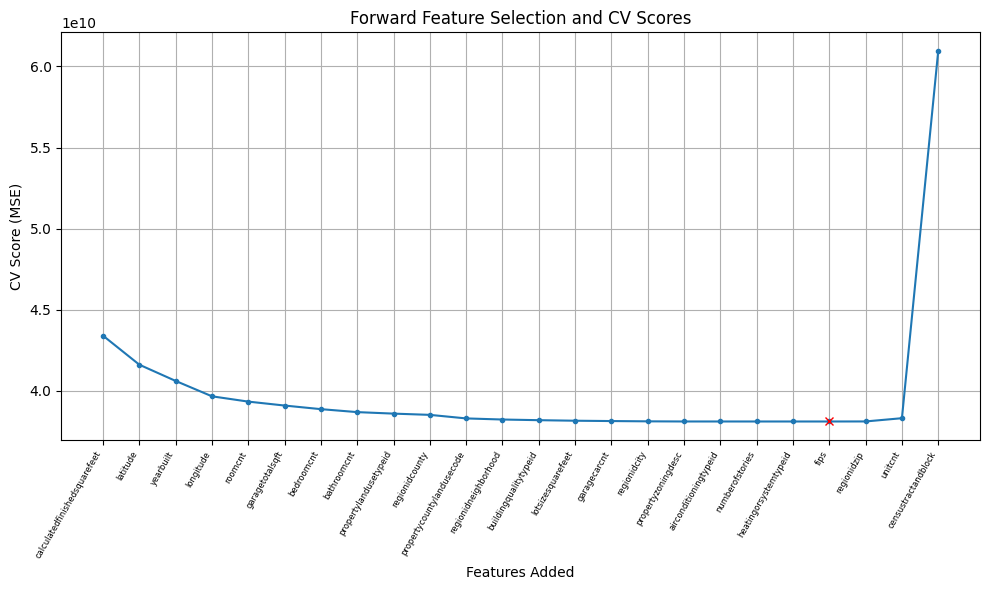

Best Features: ['calculatedfinishedsquarefeet', 'latitude', 'yearbuilt', 'longitude', 'roomcnt', 'garagetotalsqft', 'bedroomcnt', 'bathroomcnt', 'propertylandusetypeid', 'regionidcounty', 'propertycountylandusecode', 'regionidneighborhood', 'buildingqualitytypeid', 'lotsizesquarefeet', 'garagecarcnt', 'regionidcity', 'propertyzoningdesc', 'airconditioningtypeid', 'numberofstories', 'heatingorsystemtypeid', 'fips']
Best CV Score: 38111431570.3072
RMSE: 195145.2352


In [ ]:
#forward Feature Selection using this dataset:

model = LinearRegression()

selected_features, best_scores, best_forward_features, best_score =    (
            forward_feature_selection(X, y, model, verbose=True) )

# Plot the results

index = np.argmax(np.array(selected_features) == best_forward_features[-1])

plt.figure(figsize=(10, 6))
plt.plot(range(1, len(best_scores) + 1), best_scores, marker='.')
plt.plot([index+1],best_score,marker='x',color='red')
plt.xticks(range(1, len(selected_features) + 1), selected_features, rotation=60, ha='right', fontsize=6)
plt.title('Forward Feature Selection and CV Scores')
plt.xlabel('Features Added')
plt.ylabel('CV Score (MSE)')
plt.grid()
plt.tight_layout()
plt.show()

# Print the best subset and score
print(f"Best Features: {best_forward_features}")
print(f"Best CV Score: {best_score:.4f}")

# Testing


X_best = X[best_forward_features]


model = LinearRegression()
model.fit(X_best, y)

y_pred = model.predict(X_best)

rmse = np.sqrt(mean_squared_error(y, y_pred))

print(f"RMSE: {rmse:.4f}")

In [97]:
# Backward Feature Selection Template Code

def backward_feature_selection(X, y, model, 
                               scoring='neg_mean_squared_error', 
                               cv=5, 
                               tol=None,               # None = no delta cutoff
                                                       # use 0.0 for "no further improvements"
                                                       # and 1e-4 for "point of diminishing returns"                                      
                               max_features=None,      # If None, remove features until only 1 remains
                                                       # Otherwise, stop when this many features remain
                               n_jobs=-1,
                               verbose=True
                              ):
    
    # Helper function to compute CV score using LinearRegression
    def cv_score(features):
        return -cross_val_score(model, X[features], y, 
                                scoring=scoring, cv=cv, 
                                n_jobs=n_jobs          ).mean()
    
    # Start with all features (using a list for easier manipulation)
    features_remaining = list(X.columns)
    
    # Compute initial CV score with the full feature set
    initial_score = cv_score(features_remaining)
    
    # Initialize tracking variables
    best_score        = initial_score                # Best (lowest) CV score observed so far
    best_feature_set  = features_remaining.copy()    # Feature set corresponding to best_score
    selected_features = ['NONE']                     # List to record the order in which features are removed
    best_scores       = [initial_score]              # List to record the CV score after each removal (starting with full set)
    
    if verbose:
        print("Start with full set of features:")
        print(f'{features_remaining}  CV score (MSE): {np.around(initial_score, 4)}\n')
    
    # Determine the target number of features to keep:
    # For backward elimination, if max_features is None, we remove until 1 feature remains.
    target_feature_count = 1 if max_features is None else max_features
    
    prev_score = initial_score
    round_num = 1
    # Continue removing features until we reach the target count
    while len(features_remaining) > target_feature_count:
        if verbose:
            print(f'Round {round_num}:')
            
        # Initialize variables to track the best removal in this round
        lowest_score = float('inf')
        feature_to_remove = None
        best_new_features = None
        
        # Try removing each feature one at a time
        for feature in features_remaining:
            new_feature_set = features_remaining.copy()
            new_feature_set.remove(feature)
            new_score = cv_score(new_feature_set)
            if verbose:
                print('Trying removal of:',feature, np.around(new_score, 4))
            if new_score < lowest_score:
                lowest_score = new_score
                feature_to_remove = feature
                best_new_features = new_feature_set
        
        # Check if improvement is significant enough (if tol is set)
        if tol is not None and (prev_score - lowest_score) < tol:
            if verbose:
                print("\nStopping early due to minimal improvement.")
            break
        
        # Update the best score and feature set if current removal improves performance
        if lowest_score < best_score:
            best_score = lowest_score
            best_feature_set = best_new_features.copy()
        
        # Update trackers for this round
        prev_score = lowest_score
        features_remaining = best_new_features
        selected_features.append(feature_to_remove)
        best_scores.append(lowest_score)
        
        if verbose:
            print(f'\nRemoving {feature_to_remove}:  CV score (MSE) {np.around(lowest_score, 4)}\n')
        round_num += 1

    return (
        selected_features,      # Order in which features were removed
        best_scores,            # CV scores after each removal step
        best_feature_set,       # Feature set that achieved the best CV score
        best_score              # Best (lowest) CV score
    )


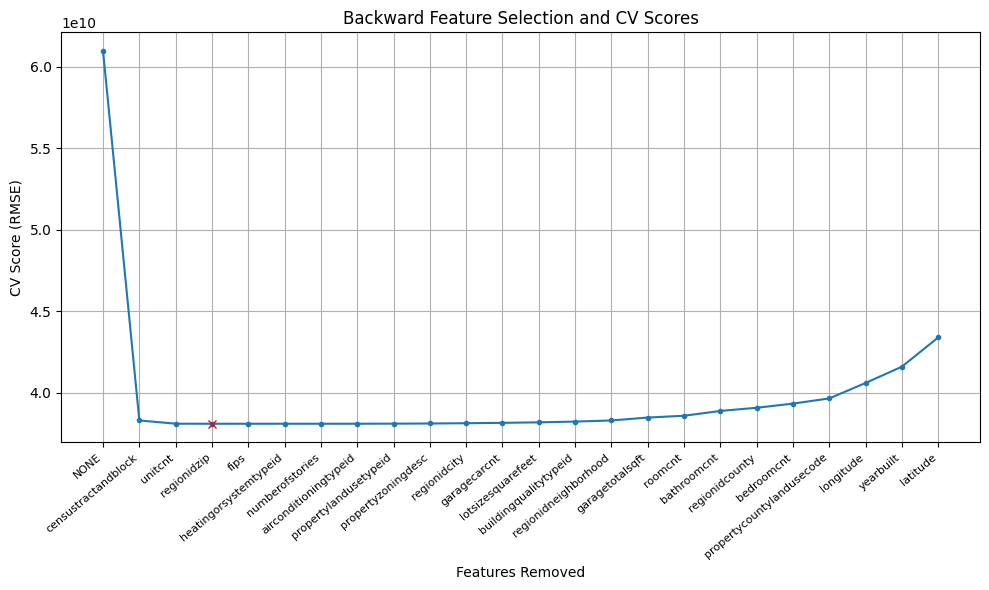

Best feature set: ['airconditioningtypeid', 'bathroomcnt', 'bedroomcnt', 'buildingqualitytypeid', 'calculatedfinishedsquarefeet', 'fips', 'garagecarcnt', 'garagetotalsqft', 'heatingorsystemtypeid', 'latitude', 'longitude', 'lotsizesquarefeet', 'propertycountylandusecode', 'propertylandusetypeid', 'propertyzoningdesc', 'regionidcity', 'regionidcounty', 'regionidneighborhood', 'roomcnt', 'yearbuilt', 'numberofstories']
CV score (MSE): 38111431570.3053
MSE: 38081662829.0950


In [99]:
# run backward selection and display results

model = LinearRegression()

selected_features, best_scores, best_feature_set, best_score = (
    backward_feature_selection(X, y, model, verbose=False)                             
)

plt.figure(figsize=(10, 6))
plt.title('Backward Feature Selection and CV Scores')
plt.plot(range(1, len(best_scores) + 1), best_scores, marker='.')
index = np.argmin(best_scores) 
plt.plot([index + 1], best_scores[index], marker='x', color='red')  
plt.xticks(range(1, len(selected_features) + 1), selected_features, rotation=40, ha='right', fontsize=8)
plt.xlabel('Features Removed')
plt.ylabel('CV Score (RMSE)')
plt.grid()
plt.tight_layout()
plt.show()

# Print minimum cv score

print("Best feature set:", best_feature_set)
print("CV score (MSE):",np.around(best_score,4))


# Test

# Filter X_train and X_test to include only the selected features
X_best_backward = X[best_feature_set]


# Train the LinearRegression model on the selected features
model = LinearRegression()
model.fit(X_best_backward, y)


y_pred = model.predict(X_best_backward)


mse = mean_squared_error(y, y_pred)

print(f"MSE: {mse:.4f}")

#### **4.A Discussion:**  Describe in a paragraph what you see in the feature relationships and correlations.

Pay particular attention to especially interesting and/or strongly correlated feature relationships. 
 How do the different methods for seeing relationships compare? Do they agree or disagree?



The correlation matrix and the F-Score both point towards Square Footage and Bathroom count being the highest correlated with Tax Valuation. The Backward feature selection imply that latitude, year built, longitude are not highly correlated with the Tax Valuation. The forward selection seuggests that the cencus data is also not highly correlated with Tax Valuation. The methods all offer a different view of how the features correspond with the target column. They do not totally agree, but that is OK as different approaches show which data is important to investigate. 

### Part 4.B:  2-Dimensional Visualizations for Interesting Patterns  
   - Select three (3) pairs of features that exhibit meaningful relationships based on your previous analysis. 
   - Create 2D scatter plots or density plots to explore interactions between these features.  
   - Provide brief interpretations of any observed patterns or trends. 

#### **4.B Discussion:** Provide brief interpretations of any observed patterns or trends.


## Part 5:  Feature Engineering: Investigate various transformations to better expose the underlying data patterns to machine learning algorithms. [6 pts]

**Important Notes:**  
- This last part is a bit open ended, since there is a huge variety of feature engineering techniques, most of which won't be useful for your particular dataset. 
- Understand that you can't evaluate the final usefulness of these transformations
until you choose a model, and  models may respond differently to various transformations or obviate some transformations (e.g., ensemble methods already do feature selection). 
- Therefore, write your transformations as functions or otherwise be prepared
to choose later on which transformations may be necessary. 

**Investigate feature engineering, where appropriate:**

- Feature scaling: standardize or normalize features as necessary
- Decompose features (e.g., categorical into One-Hot feature sequence, date/time into two features data and time, etc.).
- Add promising transformations of features
    - Exponential $\exp(x_i)$ or logarithmic $\log(x_j)$
    - Polynomial features  ( $x_i^2$, $x_i - x_j$), products ($x_i*x_j$), or ratios ($x_i/x_j$)

**ToDo:**
- Pick at least three transformations to try.
- Try each one and evaluate its effect using correlations or F-scores or a feature selection algorithm.
- Answer the discussion question. 

#### **5 Discussion:** Describe in a paragraph why you chose these transformations and what you observed. 


## **Appendix 1: Features of the Zillow Dataset**  

0. **parcelid**: Unique identifier for the property parcel.  
1. **airconditioningtypeid**: Identifier for the type of air conditioning installed.  
2. **architecturalstyletypeid**: Identifier for the architectural style of the property.  
3. **basementsqft**: Square footage of the basement.  
4. **bathroomcnt**: Number of bathrooms.  
5. **bedroomcnt**: Number of bedrooms.  
6. **buildingclasstypeid**: Identifier for the building framing type (e.g., wood frame, steel frame).  
7. **buildingqualitytypeid**: Numeric value indicating the quality of the building (higher values often indicate better quality).  
8. **calculatedbathnbr**: Calculated number of bathrooms, including fractional bathrooms.  
9. **decktypeid**: Identifier for the type of deck.  
10. **finishedfloor1squarefeet**: Square footage of the finished area on the first floor.  
11. **calculatedfinishedsquarefeet**: Total finished living area square footage.  
12. **finishedsquarefeet12**: Finished living area square footage.  
13. **finishedsquarefeet13**: Perimeter living area square footage.  
14. **finishedsquarefeet15**: Total area.  
15. **finishedsquarefeet50**: Square footage of the finished area on the upper floors.  
16. **finishedsquarefeet6**: Base unfinished and finished area square footage.  
17. **fips**: Federal Information Processing Standards code, uniquely identifying counties and county equivalents.  
18. **fireplacecnt**: Number of fireplaces.  
19. **fullbathcnt**: Number of full bathrooms.  
20. **garagecarcnt**: Number of cars that can fit in the garage.  
21. **garagetotalsqft**: Total square footage of the garage.  
22. **hashottuborspa**: Indicates if the property has a hot tub or spa.  
23. **heatingorsystemtypeid**: Identifier for the type of heating system.  
24. **latitude**: Latitude coordinate of the property.  
25. **longitude**: Longitude coordinate of the property.  
26. **lotsizesquarefeet**: Lot size in square feet.  
27. **poolcnt**: Number of pools on the property.  
28. **poolsizesum**: Total square footage of all pools.  
29. **pooltypeid10**: Identifier for spa or hot tub.  
30. **pooltypeid2**: Identifier for pool with spa or hot tub.  
31. **pooltypeid7**: Identifier for pool without hot tub or spa.  
32. **propertycountylandusecode**: County land use code for the property.  
33. **propertylandusetypeid**: Identifier for the property land use type.  
34. **propertyzoningdesc**: Description of the property's zoning.  
35. **rawcensustractandblock**: Unprocessed census tract and block identifier.  
36. **regionidcity**: Identifier for the city.  
37. **regionidcounty**: Identifier for the county.  
38. **regionidneighborhood**: Identifier for the neighborhood.  
39. **regionidzip**: Identifier for the ZIP code.  
40. **roomcnt**: Total number of rooms.  
41. **storytypeid**: Identifier for the type of stories in the building (e.g., basement, attic).  
42. **threequarterbathnbr**: Number of 3/4 bathrooms (typically includes a shower but no tub).  
43. **typeconstructiontypeid**: Identifier for the type of construction (e.g., frame, masonry).  
44. **unitcnt**: Number of units in the building (e.g., for multi-family properties).  
45. **yardbuildingsqft17**: Square footage of the 17th yard building (e.g., shed).  
46. **yardbuildingsqft26**: Square footage of the 26th yard building.  
47. **yearbuilt**: Year the property was built.  
48. **numberofstories**: Number of stories in the building.  
49. **fireplaceflag**: Indicates if the property has a fireplace.  
50. **assessmentyear**: Year the property was assessed.  
51. **taxdelinquencyflag**: Indicates whether the property’s taxes are delinquent. Often “Y” if taxes are past due; otherwise null/empty.  
52. **taxdelinquencyyear**: The year in which the property’s taxes became delinquent.  
53. **censustractandblock**: A combined identifier for the property’s census tract and block group (part of the U.S. Census geographic hierarchy).  
54. **taxvaluedollarcnt**: Total assessed value of the property (land plus structure) in dollars.  


## Appendix 2: Summary of Basic Imputation Methods
Imputation depends on the data type and context. Below are common techniques for handling missing values.

---

### **1. Simple Imputation (Basic Methods)**
| Method | Best For | Code Example | Pros | Cons |
|--------|---------|--------------|------|------|
| **Drop Missing Values** | Few missing values (<5% of data) | `df.dropna()` | Quick and easy | Can remove valuable data |
| **Mean Imputation** | Normally distributed numerical data | `df.fillna(df.mean())` | Preserves mean; simple | Distorts variance, weak for skewed data |
| **Median Imputation** | Skewed numerical data | `df.fillna(df.median())` | Robust to outliers | May not capture patterns |
| **Mode Imputation** | Categorical features | `df.fillna(df.mode().iloc[0])` | Keeps most common category | Can introduce bias |
| **Constant Value (e.g., 0)** | Special cases (e.g., unknown numerical data) | `df.fillna(0)` | Simple and interpretable | Can mislead model |
| **"Unknown" Category Imputation** (**New Addition**) | Categorical features with missing values | `df.fillna('Unknown')` | Keeps all rows, prevents data loss | May introduce artificial category |

---

### **2. Statistical & Advanced Imputation**
| Method | Best For | Code Example | Pros | Cons |
|--------|---------|--------------|------|------|
| **Interpolation** | Time series, ordered data | `df.interpolate(method='linear')` | Preserves trends | May not work for non-continuous data |
| **K-Nearest Neighbors (KNN)** | Small datasets, patterns in features | `KNNImputer(n_neighbors=5).fit_transform(df)` | Uses similar observations | Computationally expensive |
| **Multivariate Imputation (MICE)** | Complex relationships between variables | `IterativeImputer().fit_transform(df)` | Captures relationships | Slower than mean/median |
| **Regression Imputation** | When missing values depend on other variables | Train regression model to predict missing values | More accurate than mean/median | Risk of overfitting |

---

### **When to Use "Unknown" Category for Categorical Imputation**
✅ **Good for:**
- Categorical features where missing values may indicate meaningful differences.  
- Customer data (e.g., missing survey responses → "No Response").  
- Product categories where missing could be a separate group.  

❌ **Avoid if:**
- The missing category does **not** have a meaningful interpretation.
- The model might learn spurious patterns from an artificial category.

---

### **Which Method to Choose?**
| Scenario | Best Method |
|----------|------------|
| **Few missing values (<5%)** | Drop NaNs (`df.dropna()`) |
| **Numerical & normal distribution** | Mean (`df.fillna(df.mean())`) |
| **Numerical & skewed distribution** | Median (`df.fillna(df.median())`) |
| **Categorical features** | Mode (`df.fillna(df.mode().iloc[0])`) |
| **Categorical with possible meaning in missingness** | "Unknown" Category (`df.fillna('Unknown')`) |
| **Small dataset with patterns** | KNN Imputer (`KNNImputer()`) |
| **Complex relationships between features** | MICE / Iterative Imputer |

